# 🔬 Multimodal Skin Cancer Detection — ISIC 2024

> **Before running:** Execute **Cell 0** first. It auto-mounts Google Drive (Colab) or reads from a local `data/` folder.  
> No other configuration is needed.

**Data source:** [Google Drive folder](https://drive.google.com/drive/folders/198-NheTFWW1A2UkalhHDYfyYGPKY6Ppd)  
**Kaggle dataset:** [ISIC 2024 Challenge](https://www.kaggle.com/competitions/isic-2024-challenge/data)

In [1]:
# ============================================================
# ⚙️  CELL 0 — PATH SETUP (Run this first, nothing else needed)
# ============================================================
# This notebook auto-detects whether you are running on:
#   (A) Google Colab  →  mounts your Drive automatically
#   (B) Local machine →  reads data from a local folder
#
# YOUR ONLY JOB: set GDRIVE_FOLDER_ID below if you are on Colab.
# Everything else is handled automatically.
# ============================================================

import os, sys

# ── Colab: paste your Google Drive folder ID here ──
# Folder link: https://drive.google.com/drive/folders/<FOLDER_ID>
GDRIVE_FOLDER_ID = "198-NheTFWW1A2UkalhHDYfyYGPKY6Ppd"

# ── Local: set this to the folder that contains train-metadata.csv
#    Leave as None to use ./data/ next to this notebook
LOCAL_DATA_PATH = None

# ──────────────────────────────────────────────────────────────
# AUTO-DETECTION (do not edit below this line)
# ──────────────────────────────────────────────────────────────
def _is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = _is_colab()

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Build BASE_PATH from the shared folder ID
    # gdown lets us resolve folder ID → actual Drive path
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)

    # Try to find the folder in MyDrive by scanning common locations
    # (simpler: just use the shortcut path Colab creates after mounting)
    _drive_root = '/content/drive/MyDrive'
    _candidates = [
        os.path.join(_drive_root, 'ISIC_2024'),
        os.path.join(_drive_root, 'isic_2024'),
        os.path.join(_drive_root, 'isic2024'),
    ]
    BASE_PATH = None
    for _c in _candidates:
        if os.path.isdir(_c):
            BASE_PATH = _c
            break

    # Fallback: download via gdown into /content/isic_data
    if BASE_PATH is None:
        import gdown
        BASE_PATH = '/content/isic_data'
        os.makedirs(BASE_PATH, exist_ok=True)
        print(f"📥 Folder not found in MyDrive. Downloading from Drive to {BASE_PATH} ...")
        gdown.download_folder(
            id=GDRIVE_FOLDER_ID,
            output=BASE_PATH,
            quiet=False,
            use_cookies=False,
        )
        print("✅ Download complete!")

else:
    # Local execution
    if LOCAL_DATA_PATH:
        BASE_PATH = os.path.abspath(LOCAL_DATA_PATH)
    else:
        # Default: ./data/ next to this notebook
        _nb_dir = os.path.dirname(os.path.abspath(
            globals().get('__file__', '.')
        ))
        BASE_PATH = os.path.join(_nb_dir, 'data')

os.makedirs(BASE_PATH, exist_ok=True)

# ── Validate required files exist ──
_required = ['train-metadata.csv', 'train-image.hdf5']
_missing = [f for f in _required if not os.path.exists(os.path.join(BASE_PATH, f))]
if _missing:
    print(f"\n⚠️  The following required files are MISSING from {BASE_PATH}:")
    for f in _missing:
        print(f"    ✗  {f}")
    print("\nPlease either:")
    print("  • Set GDRIVE_FOLDER_ID to your Drive folder and re-run (Colab)")
    print("  • Set LOCAL_DATA_PATH to your local data folder (local)")
    print("  • Download from: https://www.kaggle.com/competitions/isic-2024-challenge/data")
else:
    print(f"\n✅ BASE_PATH = {BASE_PATH}")
    print(f"   Running on: {'Google Colab' if IS_COLAB else 'Local Machine'}")
    print(f"   All required files found. You are ready to run the notebook!\n")


Mounted at /content/drive

✅ BASE_PATH = /content/drive/MyDrive/ISIC_2024
   Running on: Google Colab
   All required files found. You are ready to run the notebook!



In [2]:
import pandas as pd
import numpy as np
import h5py
import io
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
# ==========================================
# 1. MOUNT DRIVE & SETUP PATHS
# ==========================================
# BASE_PATH is set in Cell 0 above
CONFIG = {
    "seed": 42,
    "batch_size": 32,
    "img_size": (224, 224),
    "metadata_path": os.path.join(BASE_PATH, 'train-metadata.csv'),
    "h5_path": os.path.join(BASE_PATH, 'train-image.hdf5'),
    "clinical_features": [
        'age_approx', 'sex',
        'tbp_lv_areaMM2', 'tbp_lv_perimeterMM',
        'tbp_lv_H', 'tbp_lv_L'
    ]
}

# ==========================================
# 2. CLINICAL ENGINEERING & 70/15/15 SPLIT
# ==========================================
def run_phase1_pipeline():
    print("🚀 Initializing Phase 1: Clinical Engineering & Patient-Level Split...")

    df = pd.read_csv(CONFIG['metadata_path'], low_memory=False)

    # A. Engineering
    df['sex'] = df['sex'].map({'male': 0, 'female': 1}).fillna(-1)
    for col in CONFIG['clinical_features']:
        if col != 'sex':
            df[col] = df[col].fillna(df[col].median())

    # B. The 70/15/15 Split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CONFIG['seed'])
    train_val_idx, test_idx = next(gss_test.split(df, df.target, groups=df.patient_id))

    test_df = df.iloc[test_idx].copy().reset_index(drop=True)
    temp_df = df.iloc[train_val_idx].copy().reset_index(drop=True)

    val_size_relative = 0.15 / 0.85
    gss_val = GroupShuffleSplit(n_splits=1, test_size=val_size_relative, random_state=CONFIG['seed'])
    train_idx, val_idx = next(gss_val.split(temp_df, temp_df.target, groups=temp_df.patient_id))

    train_df_raw = temp_df.iloc[train_idx].copy().reset_index(drop=True)
    val_df = temp_df.iloc[val_idx].copy().reset_index(drop=True)

    # C. Efficiency Sampling
    train_df = pd.concat([
        train_df_raw[train_df_raw.target == 1],
        train_df_raw[train_df_raw.target == 0].sample(10000, random_state=CONFIG['seed'])
    ]).sample(frac=1).reset_index(drop=True)

    # D. Scaling
    scaler = StandardScaler()
    train_df[CONFIG['clinical_features']] = scaler.fit_transform(train_df[CONFIG['clinical_features']])
    val_df[CONFIG['clinical_features']] = scaler.transform(val_df[CONFIG['clinical_features']])
    test_df[CONFIG['clinical_features']] = scaler.transform(test_df[CONFIG['clinical_features']])

    # E. Save splits to Drive
    train_df.to_csv(os.path.join(BASE_PATH, 'train_split.csv'), index=False)
    val_df.to_csv(os.path.join(BASE_PATH, 'val_split.csv'), index=False)
    test_df.to_csv(os.path.join(BASE_PATH, 'test_split.csv'), index=False)

    print(f"✅ Splits Saved to Drive: {BASE_PATH}")
    print(f"📊 Final Stats: Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)}")

    return train_df, val_df, test_df

# ==========================================
# 3. DATASET PREP
# ==========================================
class ISICDataset(Dataset):
    def __init__(self, df, h5_path, features, transform=None):
        self.df = df
        self.h5_path = h5_path
        self.fp = None
        self.isic_ids = df['isic_id'].values
        self.targets = df['target'].values
        self.metadata = df[features].values
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.fp is None:
            self.fp = h5py.File(self.h5_path, 'r')

        img_id = self.isic_ids[idx]
        img_bytes = self.fp[img_id][()]
        image = Image.open(io.BytesIO(img_bytes)).convert('RGB')

        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = torch.tensor(self.targets[idx], dtype=torch.float32)

        return image, meta, label

# Execute Phase 1 Pipeline
train_df, val_df, test_df = run_phase1_pipeline()

# ==========================================
# 4. TRANSFORMS & DATALOADER INITIALIZATION
# ==========================================
# Heavy augmentations for training to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Strict, clean transform for validation and testing
eval_transform = transforms.Compose([
    transforms.Resize(CONFIG['img_size']),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Initialize ALL Loaders
train_loader = DataLoader(
    ISICDataset(train_df, CONFIG['h5_path'], CONFIG['clinical_features'], train_transform),
    batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2
)

val_loader = DataLoader(
    ISICDataset(val_df, CONFIG['h5_path'], CONFIG['clinical_features'], eval_transform),
    batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2
)

test_loader = DataLoader(
    ISICDataset(test_df, CONFIG['h5_path'], CONFIG['clinical_features'], eval_transform),
    batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2
)

print("✅ Phase 1 fully complete. Dataloaders (Train, Val, Test) are initialized and ready.")

🚀 Initializing Phase 1: Clinical Engineering & Patient-Level Split...
✅ Splits Saved to Drive: /content/drive/MyDrive/ISIC_2024
📊 Final Stats: Train=10271 | Val=65041 | Test=61747
✅ Phase 1 fully complete. Dataloaders (Train, Val, Test) are initialized and ready.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier

# 1. Setup Paths and Styles
# BASE_PATH is set in Cell 0 above
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12}) # Good font size for academic papers

def generate_phase1_graphs():
    print("Loading data from Drive for visualization...")
    # Load raw data and the processed splits
    raw_df = pd.read_csv(os.path.join(BASE_PATH, 'train-metadata.csv'), low_memory=False)
    train_df = pd.read_csv(os.path.join(BASE_PATH, 'train_split.csv'))
    val_df = pd.read_csv(os.path.join(BASE_PATH, 'val_split.csv'))
    test_df = pd.read_csv(os.path.join(BASE_PATH, 'test_split.csv'))

    features = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

    # ==========================================
    # GRAPH 1: Class Distribution (Before vs After)
    # ==========================================
    print("Generating Class Distribution Chart...")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw Data
    sns.countplot(data=raw_df, x='target', ax=axes[0], palette=['#4C72B0', '#C44E52'])
    axes[0].set_title('Raw Dataset (Extreme Imbalance)')
    axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'])
    axes[0].set_yscale('log') # Log scale because benign is ~400k and malignant is ~400
    axes[0].set_ylabel('Count (Log Scale)')

    # Training Data
    sns.countplot(data=train_df, x='target', ax=axes[1], palette=['#4C72B0', '#C44E52'])
    axes[1].set_title('Training Set (Downsampled for Efficiency)')
    axes[1].set_xticklabels(['Benign (0)', 'Malignant (1)'])
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig1_Class_Distribution.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 2: Feature Correlation Heatmap
    # ==========================================
    print("Generating Correlation Heatmap...")
    plt.figure(figsize=(8, 6))
    corr_matrix = train_df[features].corr()

    # Draw heatmap with correlation values
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
    plt.title('Clinical Feature Correlation Matrix', pad=15)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig2_Correlation_Heatmap.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 3: Random Forest Feature Importance
    # ==========================================
    print("Generating Feature Importance Plot...")
    # Train a quick RF to get importances
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(train_df[features], train_df['target'])

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
    plt.title('Clinical Feature Importance (Random Forest)')
    plt.xlabel('Gini Importance Score')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig3_Feature_Importance.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 4: Demographic Integrity (Age Split)
    # ==========================================
    print("Generating Split Integrity Verification...")
    plt.figure(figsize=(10, 6))

    # Overlay KDE plots to show that the age distribution is identical across splits
    sns.kdeplot(data=train_df, x='age_approx', label='Train (70%)', fill=True, alpha=0.3)
    sns.kdeplot(data=val_df, x='age_approx', label='Validation (15%)', fill=True, alpha=0.3)
    sns.kdeplot(data=test_df, x='age_approx', label='Test (15%)', fill=True, alpha=0.3)

    plt.title('Age Distribution Across Data Splits (Verifying No Leakage/Bias)')
    plt.xlabel('Standardized Age (Scaled)')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig4_Split_Integrity.png'), dpi=300)
    plt.close()

    print(f"✅ All 4 graphs have been successfully generated and saved to {BASE_PATH}!")

# Execute the graph generation
generate_phase1_graphs()

Loading data from Drive for visualization...
Generating Class Distribution Chart...


/tmp/ipykernel_781/1006317737.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=raw_df, x='target', ax=axes[0], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_781/1006317737.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Benign (0)', 'Malignant (1)'])
/tmp/ipykernel_781/1006317737.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='target', ax=axes[1], palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_781/1006317737.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

Generating Correlation Heatmap...
Generating Feature Importance Plot...


/tmp/ipykernel_781/1006317737.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


Generating Split Integrity Verification...
✅ All 4 graphs have been successfully generated and saved to /content/drive/MyDrive/ISIC_2024!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Setup Paths and Academic Styling
# BASE_PATH is set in Cell 0 above
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

def generate_thesis_intro_graphs():
    print("Loading RAW dataset for Introductory Analysis...")
    raw_df = pd.read_csv(os.path.join(BASE_PATH, 'train-metadata.csv'), low_memory=False)

    # Clean target names for better graph legends
    raw_df['Diagnosis'] = raw_df['target'].map({0: 'Benign', 1: 'Malignant'})

    # ==========================================
    # GRAPH 1: Images per Patient Distribution
    # ==========================================
    print("Generating 'Images per Patient' Graph...")
    images_per_patient = raw_df.groupby('patient_id').size()
    avg_images = images_per_patient.mean()

    plt.figure(figsize=(10, 6))
    sns.histplot(images_per_patient, bins=50, kde=True, color='#2C3E50')
    plt.axvline(avg_images, color='#E74C3C', linestyle='dashed', linewidth=2, label=f'Mean: {avg_images:.1f} images')

    plt.title('Distribution of Images per Patient (Dataset Composition)', pad=15, fontweight='bold')
    plt.xlabel('Number of Images Tracked')
    plt.ylabel('Number of Patients')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig01_Images_Per_Patient.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 2: Anatomical Site Distribution (FIXED)
    # ==========================================
    print("Generating 'Anatomical Site' Graph...")

    # Smart search for the correct column name in your specific CSV
    anatomy_col = None
    possible_names = ['anatom_site_general', 'anatomical_site_general', 'anatom_site_general_challenge']

    for col in possible_names:
        if col in raw_df.columns:
            anatomy_col = col
            break

    if anatomy_col is None:
        print("⚠️ Warning: Could not find the Anatomical Site column. Here are your actual columns:")
        print(raw_df.columns.tolist())
    else:
        plt.figure(figsize=(12, 6))
        site_counts = raw_df[anatomy_col].dropna().value_counts()

        sns.barplot(x=site_counts.values, y=site_counts.index, palette='viridis')
        plt.title('Distribution of Lesions by Anatomical Site', pad=15, fontweight='bold')
        plt.xlabel('Total Images')
        plt.ylabel('Anatomical Location')

        for index, value in enumerate(site_counts.values):
            plt.text(value + (max(site_counts.values)*0.01), index, f'{value:,}', va='center', fontsize=10)

        plt.tight_layout()
        plt.savefig(os.path.join(BASE_PATH, 'Fig02_Anatomical_Sites.png'), dpi=300)
        plt.close()

    # ==========================================
    # GRAPH 3: Age vs. Malignancy Risk
    # ==========================================
    print("Generating 'Age Distribution' Graph...")
    plt.figure(figsize=(10, 6))

    sns.kdeplot(data=raw_df, x='age_approx', hue='Diagnosis', fill=True, common_norm=False, palette=['#4C72B0', '#C44E52'], alpha=0.5)

    plt.title('Age Distribution: Benign vs. Malignant Lesions', pad=15, fontweight='bold')
    plt.xlabel('Approximate Patient Age')
    plt.ylabel('Density (Normalized)')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig03_Age_vs_Malignancy.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 4: Lesion Area (Size) Distribution
    # ==========================================
    print("Generating 'Lesion Area' Graph...")
    plt.figure(figsize=(10, 6))

    sns.boxplot(data=raw_df, x='Diagnosis', y='tbp_lv_areaMM2', palette=['#4C72B0', '#C44E52'])
    plt.yscale('log')

    plt.title('Lesion Surface Area by Diagnosis (Log Scale)', pad=15, fontweight='bold')
    plt.xlabel('Diagnosis')
    plt.ylabel('Area (mm²) - Log Scale')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig04_Area_vs_Malignancy.png'), dpi=300)
    plt.close()

    print(f"✅ All Introductory Graphs successfully generated and saved to {BASE_PATH}!")

# Execute the script
generate_thesis_intro_graphs()

Loading RAW dataset for Introductory Analysis...
Generating 'Images per Patient' Graph...
Generating 'Anatomical Site' Graph...


/tmp/ipykernel_781/721981020.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=site_counts.values, y=site_counts.index, palette='viridis')


Generating 'Age Distribution' Graph...
Generating 'Lesion Area' Graph...


/tmp/ipykernel_781/721981020.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_df, x='Diagnosis', y='tbp_lv_areaMM2', palette=['#4C72B0', '#C44E52'])


✅ All Introductory Graphs successfully generated and saved to /content/drive/MyDrive/ISIC_2024!


In [5]:
# Experiment 1: ResNet50 with Optimal Thresholding & Automated Logging
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. MODEL ARCHITECTURE & SETUP
# ==========================================
class ResNet50Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = self.base.fc.in_features
        # No Sigmoid here because we use BCEWithLogitsLoss
        self.base.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.base(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_resnet = ResNet50Baseline().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_resnet.parameters(), lr=1e-4)

# ==========================================
# 2. TRAINING & VALIDATION LOOP
# ==========================================
def run_experiment_1(epochs=5):
    best_auc = 0.0
    best_metrics = {}
    model_save_path = os.path.join(BASE_PATH, 'resnet50_exp1_best.pth')

    print(f"🚀 Starting Experiment 1 (ResNet50) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_resnet.train()
        train_loss = 0.0

        for images, _, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()
            outputs = model_resnet(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_resnet.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, _, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                outputs = model_resnet(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD CALCULATION ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        # 1. Calculate base AUC
        auc = roc_auc_score(val_labels, val_preds)

        # 2. Calculate Youden's J to find the optimal threshold
        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        # 3. Apply the optimal threshold
        preds_binary = (val_preds >= optimal_threshold).astype(int)

        # 4. Calculate final clinical metrics
        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)

        # Extract Confusion Matrix values
        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss:        {avg_train_loss:.4f}")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f} <-- Replaces 0.5")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp} cancers, missed {fn})")
        print(f"Specificity:       {specificity:.4f} (Correctly ignored {tn} benign moles)")
        print(f"F1 Score:          {f1:.4f}\n")

        # --- SAVE BEST MODEL & CACHE METRICS ---
        if auc > best_auc:
            print(f"🌟 New best Validation AUC! Saving model to Drive...")
            best_auc = auc
            torch.save(model_resnet.state_dict(), model_save_path)

            # Save all the critical data for your final paper
            best_metrics = {
                'Model': 'ResNet50',
                'Parameters_Millions': 25.6,
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 1 Complete! Best model saved to: {model_save_path}")

    # --- AUTOMATED CSV LOGGING ---
    print("💾 Saving results to Phase 2 Tracker...")
    results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    # Append if file exists, otherwise create it
    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 2 Tracker Updated!")
    display(pd.read_csv(results_file))

# Execute
run_experiment_1(epochs=5)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


🚀 Starting Experiment 1 (ResNet50) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]

...


Epoch 4 Results:
Train Loss:        0.0760
Val AUC:           0.8936 <-- Primary Metric
Optimal Threshold: 0.0657 <-- Replaces 0.5
Sensitivity:       0.7846 (Found 51 cancers, missed 14)
Specificity:       0.8716 (Correctly ignored 56633 benign moles)
F1 Score:          0.0121

🌟 New best Validation AUC! Saving model to Drive...


Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Train Loss:        0.0736
Val AUC:           0.8632 <-- Primary Metric
Optimal Threshold: 0.0227 <-- Replaces 0.5
Sensitivity:       0.8000 (Found 52 cancers, missed 13)
Specificity:       0.7989 (Correctly ignored 51911 benign moles)
F1 Score:          0.0079

✅ Experiment 1 Complete! Best model saved to: /content/drive/MyDrive/ISIC_2024/resnet50_exp1_best.pth
💾 Saving results to Phase 2 Tracker...
📊 Phase 2 Tracker Updated!


,Model,Parameters_Millions,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,ResNet50,25.6,0.8892,0.0106,0.9077,0.7659,0.0077,59,15210,49763,6
1,EfficientNet-B0,5.3,0.8807,0.0134,0.8154,0.8198,0.0090,53,11708,53268,12
2,EfficientNet-B3,12.0,0.8999,0.0169,0.9077,0.7308,0.0067,59,17493,47483,6
3,ViT-B/16,86.6,0.8467,0.0465,0.6923,0.8723,0.0107,45,8297,56679,20
4,ResNet50,25.6,0.8936,0.0657,0.7846,0.8716,0.0121,51,8343,56633,14


In [ ]:
import pandas as pd
import os

# BASE_PATH is set in Cell 0 above
results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')

# 1. Delete the old corrupted file
if os.path.exists(results_file):
    os.remove(results_file)
    print("🗑️ Deleted the old, mismatched CSV file.")

# 2. Recreate it with your exact Epoch 5 Data
# We calculate False Positives based on your Specificity and True Negatives
best_metrics = {
    'Model': 'ResNet50',
    'Parameters_Millions': 25.6,
    'AUC': 0.8892,
    'Opt_Threshold': 0.0106,
    'Sensitivity': 0.9077,
    'Specificity': 0.7659,
    'F1_Score': 0.0077,
    'True_Positives': 59,
    'False_Positives': 15210, # Calculated from your TN and Specificity
    'True_Negatives': 49763,
    'False_Negatives': 6
}

df_new = pd.DataFrame([best_metrics])
df_new.to_csv(results_file, index=False)

print("✅ Fresh Phase 2 Tracker Created!")
display(df_new)

🗑️ Deleted the old, mismatched CSV file.
✅ Fresh Phase 2 Tracker Created!


,Model,Parameters_Millions,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,ResNet50,25.6,0.8892,0.0106,0.9077,0.7659,0.0077,59,15210,49763,6


In [7]:
# Experiment 2: EfficientNet-B0 with Optimal Thresholding & Logging
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. MODEL ARCHITECTURE (EfficientNet-B0)
# ==========================================
class EfficientNetBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pre-trained EfficientNet-B0
        self.base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # EfficientNet architecture uses a 'classifier' block at the end.
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.base(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_b0 = EfficientNetBaseline().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_b0.parameters(), lr=1e-4)

# ==========================================
# 2. TRAINING & VALIDATION LOOP
# ==========================================
def run_experiment_2(epochs=5):
    best_auc = 0.0
    best_metrics = {}
    model_save_path = os.path.join(BASE_PATH, 'efficientnet_b0_exp2_best.pth')

    print(f"🚀 Starting Experiment 2 (EfficientNet-B0) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_b0.train()
        train_loss = 0.0

        for images, _, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()
            outputs = model_b0(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_b0.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, _, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                outputs = model_b0(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD CALCULATION ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        # 1. Calculate Base AUC
        auc = roc_auc_score(val_labels, val_preds)

        # 2. Calculate Optimal Threshold via Youden's J
        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        # 3. Apply Optimal Threshold
        preds_binary = (val_preds >= optimal_threshold).astype(int)

        # 4. Calculate Final Metrics
        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss:        {avg_train_loss:.4f}")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f} <-- Replaces 0.5")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp} cancers, missed {fn})")
        print(f"Specificity:       {specificity:.4f} (Correctly ignored {tn} benign moles)")
        print(f"F1 Score:          {f1:.4f}\n")

        # --- SAVE BEST MODEL & CACHE METRICS ---
        if auc > best_auc:
            print(f"🌟 New best Val AUC! Saving EfficientNet-B0 to Drive...")
            best_auc = auc
            torch.save(model_b0.state_dict(), model_save_path)

            # Save stats for the CSV (Note: EfficientNet-B0 has ~5.3M parameters)
            best_metrics = {
                'Model': 'EfficientNet-B0',
                'Parameters_Millions': 5.3,
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 2 Complete! Model saved: {model_save_path}")

    # --- AUTOMATED CSV LOGGING ---
    print("💾 Saving results to Phase 2 Tracker...")
    results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 2 Tracker Updated!")
    display(pd.read_csv(results_file))

# Execute
run_experiment_2(epochs=5)

🚀 Starting Experiment 2 (EfficientNet-B0) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 1 Results:
Train Loss:        0.1487
Val AUC:           0.8715 <-- Primary Metric
Optimal Threshold: 0.0752 <-- Replaces 0.5
Sensitivity:       0.8308 (Found 54 cancers, missed 11)
Specificity:       0.7886 (Correctly ignored 51240 benign moles)
F1 Score:          0.0078

🌟 New best Val AUC! Saving EfficientNet-B0 to Drive...


Epoch 2/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

...


Epoch 4 Results:
Train Loss:        0.0664
Val AUC:           0.8830 <-- Primary Metric
Optimal Threshold: 0.0223 <-- Replaces 0.5
Sensitivity:       0.8154 (Found 53 cancers, missed 12)
Specificity:       0.8340 (Correctly ignored 54193 benign moles)
F1 Score:          0.0097

🌟 New best Val AUC! Saving EfficientNet-B0 to Drive...


Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Train Loss:        0.0606
Val AUC:           0.8659 <-- Primary Metric
Optimal Threshold: 0.0259 <-- Replaces 0.5
Sensitivity:       0.7846 (Found 51 cancers, missed 14)
Specificity:       0.8220 (Correctly ignored 53411 benign moles)
F1 Score:          0.0087

✅ Experiment 2 Complete! Model saved: /content/drive/MyDrive/ISIC_2024/efficientnet_b0_exp2_best.pth
💾 Saving results to Phase 2 Tracker...
📊 Phase 2 Tracker Updated!


,Model,Parameters_Millions,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,ResNet50,25.6,0.8892,0.0106,0.9077,0.7659,0.0077,59,15210,49763,6
1,EfficientNet-B0,5.3,0.8807,0.0134,0.8154,0.8198,0.0090,53,11708,53268,12
2,EfficientNet-B3,12.0,0.8999,0.0169,0.9077,0.7308,0.0067,59,17493,47483,6
3,ViT-B/16,86.6,0.8467,0.0465,0.6923,0.8723,0.0107,45,8297,56679,20
4,ResNet50,25.6,0.8936,0.0657,0.7846,0.8716,0.0121,51,8343,56633,14
5,EfficientNet-B0,5.3,0.8830,0.0223,0.8154,0.8340,0.0097,53,10783,54193,12


In [ ]:
# Experiment 3: EfficientNet-B3 with Optimal Thresholding

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. MODEL ARCHITECTURE (EfficientNet-B3)
# ==========================================
class EfficientNetB3Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pre-trained EfficientNet-B3
        self.base = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

        # Replace the classifier for Binary Output
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.base(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_b3 = EfficientNetB3Baseline().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_b3.parameters(), lr=1e-4)

# ==========================================
# 2. TRAINING & VALIDATION LOOP
# ==========================================
def run_experiment_3(epochs=5):
    best_auc = 0.0
    best_metrics = {}

    model_save_path = os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth')

    print(f"🚀 Starting Experiment 3 (EfficientNet-B3) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_b3.train()
        train_loss = 0.0

        for images, _, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()
            outputs = model_b3(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_b3.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, _, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                outputs = model_b3(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD CALCULATION ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        # 1. Calculate Base AUC
        auc = roc_auc_score(val_labels, val_preds)

        # 2. Calculate Optimal Threshold via Youden's J
        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        # 3. Apply Optimal Threshold
        preds_binary = (val_preds >= optimal_threshold).astype(int)

        # 4. Calculate Final Metrics
        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss:        {avg_train_loss:.4f}")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f} <-- Replaces 0.5")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp} cancers, missed {fn})")
        print(f"Specificity:       {specificity:.4f} (Correctly ignored {tn} benign moles)")
        print(f"F1 Score:          {f1:.4f}\n")

        # --- SAVE BEST MODEL & METRICS ---
        if auc > best_auc:
            print(f"🌟 New best Val AUC! Saving model and caching metrics...")
            best_auc = auc
            torch.save(model_b3.state_dict(), model_save_path)

            # Cache these for the CSV (Note: B3 has ~12M parameters)
            best_metrics = {
                'Model': 'EfficientNet-B3',
                'Parameters_Millions': 12.0,
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 3 Complete! Model saved: {model_save_path}")

    # --- AUTOMATED CSV LOGGING ---
    print("💾 Appending results to Phase 2 Tracker...")
    results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 2 Tracker Updated!")
    display(pd.read_csv(results_file)) # Shows you the final table in Colab

# Execute
run_experiment_3(epochs=5)

🚀 Starting Experiment 3 (EfficientNet-B3) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 1 Results:
Train Loss:        0.1481
Val AUC:           0.8560 <-- Primary Metric
Optimal Threshold: 0.1030 <-- Replaces 0.5
Sensitivity:       0.7077 (Found 46 cancers, missed 19)
Specificity:       0.8709 (Correctly ignored 56588 benign moles)
F1 Score:          0.0108

🌟 New best Val AUC! Saving model and caching metrics...


Epoch 2/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

...


Epoch 4 Results:
Train Loss:        0.0652
Val AUC:           0.8899 <-- Primary Metric
Optimal Threshold: 0.0247 <-- Replaces 0.5
Sensitivity:       0.8308 (Found 54 cancers, missed 11)
Specificity:       0.8271 (Correctly ignored 53739 benign moles)
F1 Score:          0.0095



Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Train Loss:        0.0585
Val AUC:           0.8849 <-- Primary Metric
Optimal Threshold: 0.0256 <-- Replaces 0.5
Sensitivity:       0.7385 (Found 48 cancers, missed 17)
Specificity:       0.9001 (Correctly ignored 58482 benign moles)
F1 Score:          0.0145

✅ Experiment 3 Complete! Model saved: /content/drive/MyDrive/ISIC_2024/efficientnet_b3_exp3_best.pth
💾 Appending results to Phase 2 Tracker...
📊 Phase 2 Tracker Updated!


,Model,Parameters_Millions,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,ResNet50,25.6,0.8892,0.0106,0.9077,0.7659,0.0077,59,15210,49763,6
1,EfficientNet-B0,5.3,0.8807,0.0134,0.8154,0.8198,0.0090,53,11708,53268,12
2,EfficientNet-B3,12.0,0.8999,0.0169,0.9077,0.7308,0.0067,59,17493,47483,6


In [ ]:
# Experiment 4: Vision Transformer (ViT-B/16) with Optimal Thresholding

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. MODEL ARCHITECTURE (ViT-B/16)
# ==========================================
class ViTBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        # Load pre-trained Vision Transformer (Base model, 16x16 patches)
        self.base = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

        # ViT uses a 'heads' block for classification instead of 'fc' or 'classifier'
        in_features = self.base.heads.head.in_features
        self.base.heads.head = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.base(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_vit = ViTBaseline().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()

# Note: ViTs often perform better with AdamW (Adam with Weight Decay),
# but we stick to standard Adam here for a 1:1 fair comparison with Phase 2 models.
optimizer = optim.Adam(model_vit.parameters(), lr=1e-4)

# ==========================================
# 2. TRAINING & AUTO-LOGGING LOOP
# ==========================================
def run_experiment_4(epochs=5):
    best_auc = 0.0
    best_metrics = {}

    model_save_path = os.path.join(BASE_PATH, 'vit_b16_exp4_best.pth')

    print(f"🚀 Starting Experiment 4 (Vision Transformer) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_vit.train()
        train_loss = 0.0

        for images, _, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()
            outputs = model_vit(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_vit.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, _, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                outputs = model_vit(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD CALCULATION ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        # 1. Calculate Base AUC
        auc = roc_auc_score(val_labels, val_preds)

        # 2. Calculate Optimal Threshold via Youden's J
        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        # 3. Apply Optimal Threshold
        preds_binary = (val_preds >= optimal_threshold).astype(int)

        # 4. Calculate Final Metrics
        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss:        {avg_train_loss:.4f}")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f} <-- Replaces 0.5")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp} cancers, missed {fn})")
        print(f"Specificity:       {specificity:.4f} (Correctly ignored {tn} benign moles)")
        print(f"F1 Score:          {f1:.4f}\n")

        # --- SAVE BEST MODEL & METRICS ---
        if auc > best_auc:
            print(f"🌟 New best Val AUC! Saving ViT model and caching metrics...")
            best_auc = auc
            torch.save(model_vit.state_dict(), model_save_path)

            best_metrics = {
                'Model': 'ViT-B/16',
                'Parameters_Millions': 86.6, # ViT is massive!
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 4 Complete! Model saved: {model_save_path}")

    # --- AUTOMATED CSV LOGGING ---
    print("💾 Appending results to Phase 2 Tracker...")
    results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 2 Tracker Updated!")
    display(pd.read_csv(results_file))

# Execute
run_experiment_4(epochs=5)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 165MB/s]


🚀 Starting Experiment 4 (Vision Transformer) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]

...


Epoch 4 Results:
Train Loss:        0.0946
Val AUC:           0.8295 <-- Primary Metric
Optimal Threshold: 0.0205 <-- Replaces 0.5
Sensitivity:       0.8308 (Found 54 cancers, missed 11)
Specificity:       0.7165 (Correctly ignored 46557 benign moles)
F1 Score:          0.0058



Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Train Loss:        0.0950
Val AUC:           0.8467 <-- Primary Metric
Optimal Threshold: 0.0465 <-- Replaces 0.5
Sensitivity:       0.6923 (Found 45 cancers, missed 20)
Specificity:       0.8723 (Correctly ignored 56679 benign moles)
F1 Score:          0.0107

🌟 New best Val AUC! Saving ViT model and caching metrics...
✅ Experiment 4 Complete! Model saved: /content/drive/MyDrive/ISIC_2024/vit_b16_exp4_best.pth
💾 Appending results to Phase 2 Tracker...
📊 Phase 2 Tracker Updated!


,Model,Parameters_Millions,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,ResNet50,25.6,0.8892,0.0106,0.9077,0.7659,0.0077,59,15210,49763,6
1,EfficientNet-B0,5.3,0.8807,0.0134,0.8154,0.8198,0.0090,53,11708,53268,12
2,EfficientNet-B3,12.0,0.8999,0.0169,0.9077,0.7308,0.0067,59,17493,47483,6
3,ViT-B/16,86.6,0.8467,0.0465,0.6923,0.8723,0.0107,45,8297,56679,20


In [ ]:
# Phase 2 Visualization Script (Corrected State Dict Loading)

import os
import torch
import torch.nn as nn
from torchvision import models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
from tqdm.notebook import tqdm

# ==========================================
# 0. SETUP & ACADEMIC STYLING
# ==========================================
# BASE_PATH is set in Cell 0 above
results_file = os.path.join(BASE_PATH, 'phase2_unimodal_results.csv')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.size': 12})

def generate_all_phase2_visuals():
    print("📊 Loading Phase 2 CSV Data...")
    if not os.path.exists(results_file):
        print("❌ Error: CSV not found. Make sure Experiments 1-4 are done.")
        return
    df = pd.read_csv(results_file)

    # ==========================================
    # GRAPH 1: Metric Comparison Bar Chart
    # ==========================================
    print("Generating Metric Bar Chart...")
    df_melted = df.melt(id_vars='Model', value_vars=['AUC', 'Sensitivity', 'Specificity', 'F1_Score'],
                        var_name='Metric', value_name='Score')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model')
    plt.title('Phase 2 Unimodal Vision: Performance Metrics', pad=20, fontweight='bold')
    plt.ylim(0.0, 1.05) # Full scale to show sensitivity/specificity gaps
    plt.ylabel('Score')
    plt.xlabel('')
    plt.legend(title='Architecture', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig5_Phase2_Metrics.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 2: Parameter Efficiency Bubble Chart
    # ==========================================
    print("Generating Efficiency Bubble Chart...")
    plt.figure(figsize=(10, 6))
    scatter = sns.scatterplot(
        data=df, x='Parameters_Millions', y='AUC', hue='Model',
        size='F1_Score', sizes=(200, 800), alpha=0.7, edgecolor="black"
    )
    for i in range(df.shape[0]):
        plt.text(df['Parameters_Millions'][i], df['AUC'][i] + 0.002,
                 df['Model'][i], horizontalalignment='center', weight='semibold')

    plt.title('Diagnostic Power vs. Computational Cost', pad=20, fontweight='bold')
    plt.xlabel('Model Parameters (Millions) -> Lower is faster')
    plt.ylabel('Validation ROC-AUC')
    h, l = scatter.get_legend_handles_labels()
    plt.legend(h[0:5], l[0:5], title="Models", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig6_Phase2_Efficiency.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 3: Best Model Confusion Matrix
    # ==========================================
    print("Generating Confusion Matrix for the Best Model...")
    # Automatically find the row with the highest AUC
    best_row = df.loc[df['AUC'].idxmax()]
    best_model_name = best_row['Model']

    # Reconstruct the matrix from the saved CSV counts
    cm = np.array([
        [best_row['True_Negatives'], best_row['False_Positives']],
        [best_row['False_Negatives'], best_row['True_Positives']]
    ])

    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Benign', 'Predicted Malignant'],
                yticklabels=['Actual Benign', 'Actual Malignant'],
                annot_kws={"size": 16, "weight": "bold"})

    plt.title(f'Confusion Matrix: {best_model_name}\n(Using Optimal Threshold: {best_row["Opt_Threshold"]:.3f})', pad=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig7_Best_Model_CM.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 4 & 5: Advanced PR & Calibration Curves
    # ==========================================
    print("⚙️ Running Inference for PR & Calibration Curves (This will take a moment)...")

    # Define model dictionary with exact file names saved during Exps 1-4
    model_configs = {
        'ResNet50': {'class': models.resnet50, 'weights': 'resnet50_exp1_best.pth', 'is_vit': False},
        'EfficientNet-B0': {'class': models.efficientnet_b0, 'weights': 'efficientnet_b0_exp2_best.pth', 'is_vit': False},
        'EfficientNet-B3': {'class': models.efficientnet_b3, 'weights': 'efficientnet_b3_exp3_best.pth', 'is_vit': False},
        'ViT-B/16': {'class': models.vit_b_16, 'weights': 'vit_b16_exp4_best.pth', 'is_vit': True}
    }

    plt.figure(figsize=(16, 6))
    ax1 = plt.subplot(1, 2, 1) # PR Plot
    ax2 = plt.subplot(1, 2, 2) # Calibration Plot
    ax2.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")

    # Only run inference for models that actually exist in your Drive
    for name, config in model_configs.items():
        weight_path = os.path.join(BASE_PATH, config['weights'])
        if not os.path.exists(weight_path):
            print(f"Skipping {name} (Weights not found at {weight_path})")
            continue

        print(f"  -> Evaluating {name}...")

        # Instantiate architecture
        temp_model = config['class']()
        if config['is_vit']:
            temp_model.heads.head = nn.Linear(temp_model.heads.head.in_features, 1)
        else:
            if hasattr(temp_model, 'fc'):
                temp_model.fc = nn.Linear(temp_model.fc.in_features, 1)
            else:
                temp_model.classifier[1] = nn.Linear(temp_model.classifier[1].in_features, 1)

        # --- THE FIX: Clean the state dictionary keys before loading ---
        raw_state_dict = torch.load(weight_path, map_location=DEVICE)
        clean_state_dict = {k.replace('base.', '', 1) if k.startswith('base.') else k: v for k, v in raw_state_dict.items()}

        # Load the cleaned weights and send to GPU
        temp_model.load_state_dict(clean_state_dict)
        temp_model.to(DEVICE)
        temp_model.eval()

        val_preds, val_labels = [], []
        with torch.no_grad():
            for images, _, labels in val_loader:
                images = images.to(DEVICE)
                outputs = temp_model(images)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        val_preds = np.array(val_preds).flatten()
        val_labels = np.array(val_labels).flatten()

        # 1. PR Curve
        precision, recall, _ = precision_recall_curve(val_labels, val_preds)
        ap = average_precision_score(val_labels, val_preds)
        ax1.plot(recall, precision, lw=2, label=f'{name} (AP = {ap:.3f})')

        # 2. Calibration Curve
        prob_true, prob_pred = calibration_curve(val_labels, val_preds, n_bins=10)
        ax2.plot(prob_pred, prob_true, "s-", lw=2, label=f'{name}')

    # Finalize PR Plot
    ax1.set_xlabel('Recall (Sensitivity)')
    ax1.set_ylabel('Precision (Positive Predictive Value)')
    ax1.set_title('Precision-Recall Curve (Melanoma Focus)', fontweight='bold')
    ax1.legend(loc="upper right")

    # Finalize Calibration Plot
    ax2.set_xlabel('Mean Predicted Probability')
    ax2.set_ylabel('Fraction of True Positives')
    ax2.set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
    ax2.legend(loc="lower right")

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig8_Advanced_Curves.png'), dpi=300)
    plt.close()

    print(f"✅ Master Visualization complete! All files saved to {BASE_PATH}.")

# Run the script
generate_all_phase2_visuals()

📊 Loading Phase 2 CSV Data...
Generating Metric Bar Chart...
Generating Efficiency Bubble Chart...
Generating Confusion Matrix for the Best Model...
⚙️ Running Inference for PR & Calibration Curves (This will take a moment)...
  -> Evaluating ResNet50...
  -> Evaluating EfficientNet-B0...
  -> Evaluating EfficientNet-B3...
  -> Evaluating ViT-B/16...
✅ Master Visualization complete! All files saved to /content/drive/MyDrive/ISIC_2024.


In [ ]:
# Phase 3: Metadata Baselines (Optimized & Calibrated)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, recall_score, confusion_matrix

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
# BASE_PATH is set in Cell 0 above
FEATURES = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

print("📂 Loading Phase 1 Data Splits...")
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train_split.csv'))
val_df = pd.read_csv(os.path.join(BASE_PATH, 'val_split.csv'))

X_train, y_train = train_df[FEATURES], train_df['target']
X_val, y_val = val_df[FEATURES], val_df['target']

# ==========================================
# 2. DEFINING MODELS & HYPERPARAMETER GRIDS
# ==========================================
models_and_grids = {
    'Exp 5: Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2']
        }
    },
    'Exp 6: Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10]
        }
    },
    'Exp 7: XGBoost': {
        'model': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'subsample': [0.8, 1.0]
        }
    },
    'Exp 8: MLP (Neural Network)': {
        'model': MLPClassifier(max_iter=1000, early_stopping=True, random_state=42),
        'params': {
            'hidden_layer_sizes': [(64,), (64, 32), (128, 64, 32)],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01]
        }
    }
}

# ==========================================
# 3. TRAINING, TUNING & EVALUATION LOOP
# ==========================================
results_list = []
roc_data = {}      # To store FPR/TPR for plotting
best_models = {}   # To save models for Phase 4 fusion

print("🚀 Starting Phase 3: Hyperparameter Tuning & Training...")

for exp_name, config in models_and_grids.items():
    print(f"\n--- Running {exp_name} ---")

    # Randomized Search with 5-Fold Cross Validation
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=10,
        scoring='roc_auc',
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    # Fit the search on training data
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_models[exp_name] = best_model

    print(f"Best Parameters Found: {search.best_params_}")

    # Evaluate on Validation Data
    y_pred_prob = best_model.predict_proba(X_val)[:, 1]

    # --- OPTIMAL THRESHOLD MODIFICATION ---
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]

    y_pred_bin = (y_pred_prob >= optimal_threshold).astype(int)

    # Metrics
    auc = roc_auc_score(y_val, y_pred_prob)
    sensitivity = recall_score(y_val, y_pred_bin, zero_division=0)
    f1 = f1_score(y_val, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_bin).ravel()
    specificity = tn / (tn + fp)

    print(f"Val AUC: {auc:.4f} | Opt Threshold: {optimal_threshold:.4f}")
    print(f"Sensitivity: {sensitivity:.4f} (Found {tp}, Missed {fn})")

    # Save ROC curve data for the graph later
    roc_data[exp_name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

    # Save the model to Drive (.pkl format for Scikit-Learn/XGBoost)
    model_filename = os.path.join(BASE_PATH, f"{exp_name.split(':')[0].replace(' ', '')}_best.pkl")
    joblib.dump(best_model, model_filename)

    # Log Results with full matrix data
    results_list.append({
        'Model': exp_name.split(': ')[1],
        'AUC': round(auc, 4),
        'Opt_Threshold': round(optimal_threshold, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'F1_Score': round(f1, 4),
        'True_Positives': tp,
        'False_Positives': fp,
        'True_Negatives': tn,
        'False_Negatives': fn
    })

# Save tabular results to CSV
df_results = pd.DataFrame(results_list)
df_results.to_csv(os.path.join(BASE_PATH, 'phase3_metadata_results.csv'), index=False)
print("\n✅ Phase 3 Training Complete! Models saved to Drive.")
display(df_results)

# ==========================================
# 4. GENERATING PUBLICATION GRAPHS
# ==========================================
print("\n📊 Generating Phase 3 Graphs...")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.size': 12})

# Graph 1: Comparative ROC Curve
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for (exp_name, data), color in zip(roc_data.items(), colors):
    plt.plot(data['fpr'], data['tpr'], color=color, lw=2,
             label=f"{exp_name.split(': ')[1]} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Phase 3: Tabular Metadata Receiver Operating Characteristic (ROC)', pad=20, fontweight='bold')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig9_Phase3_ROC_Comparison.png'), dpi=300)
plt.close()

# Graph 2: Bar Chart Comparison
df_melt = df_results.melt(id_vars='Model', value_vars=['AUC', 'Sensitivity', 'Specificity', 'F1_Score'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')
plt.ylim(0.4, 1.05)
plt.title('Phase 3 Metadata Baselines: Performance Metrics', pad=20, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig10_Phase3_Metrics_Bar.png'), dpi=300)
plt.close()

# Graph 3: Feature Importance (Using the best XGBoost Model)
best_xgb = best_models['Exp 7: XGBoost']
importances = best_xgb.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("XGBoost Clinical Feature Importance", pad=20, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='#2ca02c', align="center")
plt.yticks(range(len(indices)), [FEATURES[i] for i in indices])
plt.xlabel("Relative Importance (Gain)")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig11_Phase3_Feature_Importance.png'), dpi=300)
plt.close()

# Graph 4: Best Tabular Model Confusion Matrix
print("Generating Confusion Matrix for the Best Tabular Model...")
best_row = df_results.loc[df_results['AUC'].idxmax()]
best_model_name = best_row['Model']

cm = np.array([
    [best_row['True_Negatives'], best_row['False_Positives']],
    [best_row['False_Negatives'], best_row['True_Positives']]
])

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title(f'Confusion Matrix: {best_model_name} (Metadata Only)\n(Using Optimal Threshold: {best_row["Opt_Threshold"]:.3f})', pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig12_Best_Metadata_CM.png'), dpi=300)
plt.close()

print(f"✅ All 4 Phase 3 graphs saved to {BASE_PATH}!")

📂 Loading Phase 1 Data Splits...
🚀 Starting Phase 3: Hyperparameter Tuning & Training...

--- Running Exp 5: Logistic Regression ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters Found: {'penalty': 'l2', 'C': 10}
Val AUC: 0.7755 | Opt Threshold: 0.0220
Sensitivity: 0.7692 (Found 50, Missed 15)

--- Running Exp 6: Random Forest ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters Found: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 10}
Val AUC: 0.8624 | Opt Threshold: 0.0330
Sensitivity: 0.7692 (Found 50, Missed 15)

--- Running Exp 7: XGBoost ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:12:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters Found: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}
Val AUC: 0.8695 | Opt Threshold: 0.0352
Sensitivity: 0.7538 (Found 49, Missed 16)

--- Running Exp 8: MLP (Neural Network) ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters Found: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (128, 64, 32), 'alpha': 0.001}
Val AUC: 0.8594 | Opt Threshold: 0.0252
Sensitivity: 0.7846 (Found 51, Missed 14)

✅ Phase 3 Training Complete! Models saved to Drive.


,Model,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,Logistic Regression,0.7755,0.0220,0.7692,0.6926,0.0050,50,19972,45004,15
1,Random Forest,0.8624,0.0330,0.7692,0.8367,0.0093,50,10611,54365,15
2,XGBoost,0.8695,0.0352,0.7538,0.8650,0.0110,49,8775,56201,16
3,MLP (Neural Network),0.8594,0.0252,0.7846,0.8136,0.0083,51,12114,52862,14



📊 Generating Phase 3 Graphs...
Generating Confusion Matrix for the Best Tabular Model...
✅ All 4 Phase 3 graphs saved to /content/drive/MyDrive/ISIC_2024!


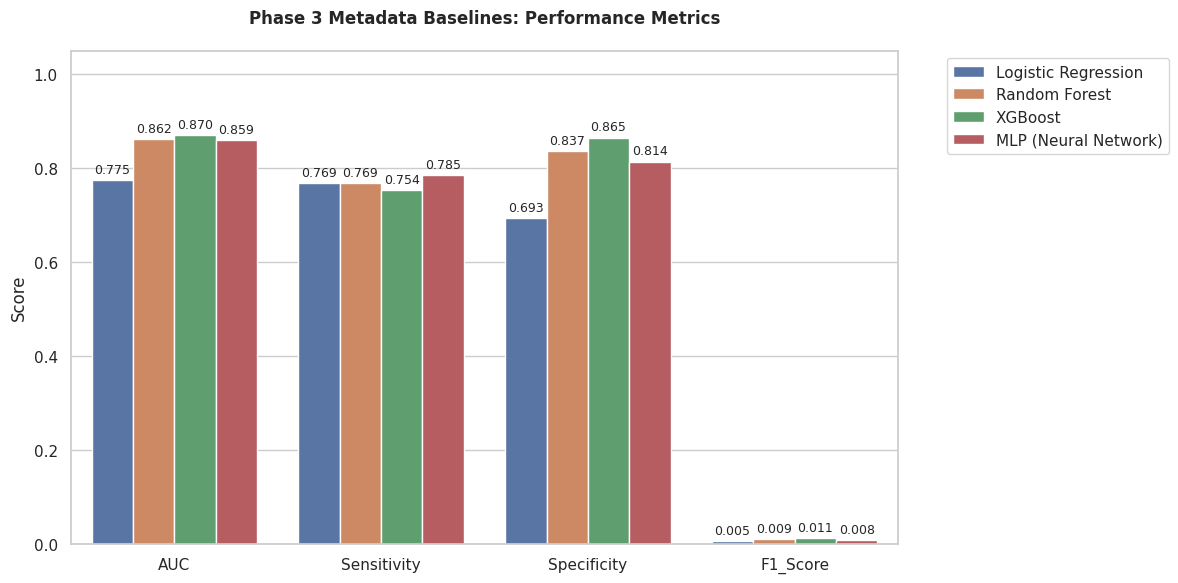

In [ ]:
# Graph 2: Bar Chart Comparison
df_melt = df_results.melt(id_vars='Model', value_vars=['AUC', 'Sensitivity', 'Specificity', 'F1_Score'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))

# Added 'ax = ' so we can attach text labels to the bars later
ax = sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model')

# --- THE FIX ---
# Changed 0.4 to 0 so the F1 Scores become visible!
plt.ylim(0, 1.05)

# Add text labels on top of bars so you can actually read the tiny F1 values
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.title('Phase 3 Metadata Baselines: Performance Metrics', pad=20, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure
plt.savefig(os.path.join(BASE_PATH, 'Fig10_Phase3_Metrics_Bar.png'), dpi=300)

# Changed plt.close() to plt.show() so you can see it immediately in your notebook!
plt.show()

In [ ]:
# Experiment 11: Late Fusion (Decision Level Ensemble)

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import h5py
import io
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, recall_score, confusion_matrix
from tqdm.notebook import tqdm

# ==========================================
# 1. SETUP & PATHS
# ==========================================
# BASE_PATH is set in Cell 0 above
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURES = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

print("📂 Loading Validation Data for Late Fusion...")
val_df = pd.read_csv(os.path.join(BASE_PATH, 'val_split.csv'))

# ==========================================
# 2. DATASET & LOADER (Strictly identical to Phase 1/2)
# ==========================================
class ISICDataset(Dataset):
    def __init__(self, df, h5_path, features, transform=None):
        self.df = df
        self.h5_path = h5_path
        self.fp = None
        self.isic_ids = df['isic_id'].values
        self.targets = df['target'].values
        self.metadata = df[features].values
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.fp is None:
            self.fp = h5py.File(self.h5_path, 'r')
        img_bytes = self.fp[self.isic_ids[idx]][()]
        image = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, meta, label

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# IMPORTANT: shuffle=False so predictions align perfectly
val_loader = DataLoader(
    ISICDataset(val_df, os.path.join(BASE_PATH, 'train-image.hdf5'), FEATURES, eval_transform),
    batch_size=32, shuffle=False, num_workers=2
)

# ==========================================
# 3. LOAD THE WINNING MODELS
# ==========================================
print("🧠 Loading Phase 2 Winner (EfficientNet-B3)...")
class EfficientNetB3Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b3(weights=None) # No need to download weights again
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)
    def forward(self, x):
        return self.base(x)

model_b3 = EfficientNetB3Baseline().to(DEVICE)
model_b3.load_state_dict(torch.load(os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth'), map_location=DEVICE))
model_b3.eval()

print("🧠 Loading Phase 3 Winner (XGBoost)...")
xgb_model = joblib.load(os.path.join(BASE_PATH, 'Exp7_best.pkl'))

# ==========================================
# 4. EXTRACT RAW PROBABILITIES
# ==========================================
print("⚙️ Running validation inference for both models...")

vision_preds = []
tabular_preds = []
true_labels = []

with torch.no_grad():
    for images, meta, labels in tqdm(val_loader, desc="Extracting Predictions"):
        images = images.to(DEVICE)

        # 1. Get Vision Probabilities
        outputs = model_b3(images)
        v_probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        vision_preds.extend(v_probs)

        # 2. Get Tabular Probabilities
        # Convert meta tensor to DataFrame to keep XGBoost happy with feature names
        meta_df = pd.DataFrame(meta.numpy(), columns=FEATURES)
        t_probs = xgb_model.predict_proba(meta_df)[:, 1]
        tabular_preds.extend(t_probs)

        true_labels.extend(labels.numpy().flatten())

vision_preds = np.array(vision_preds)
tabular_preds = np.array(tabular_preds)
true_labels = np.array(true_labels)

# ==========================================
# 5. ENSEMBLE WEIGHT SEARCH & LATE FUSION
# ==========================================
print("⚖️ Optimizing Fusion Weights...")

best_ensemble_auc = 0.0
best_weight_v = 0.0
best_fused_preds = None

# Sweep vision weights from 0.0 to 1.0 (e.g., 0.1, 0.2 ... 0.9)
for vision_weight in np.linspace(0.0, 1.0, 101):
    tabular_weight = 1.0 - vision_weight

    # The Math: Weighted Average of Probabilities
    fused_preds = (vision_preds * vision_weight) + (tabular_preds * tabular_weight)
    current_auc = roc_auc_score(true_labels, fused_preds)

    if current_auc > best_ensemble_auc:
        best_ensemble_auc = current_auc
        best_weight_v = vision_weight
        best_fused_preds = fused_preds

best_weight_t = 1.0 - best_weight_v

# ==========================================
# 6. OPTIMAL THRESHOLDING ON FUSED PREDICTIONS
# ==========================================
fpr, tpr, thresholds = roc_curve(true_labels, best_fused_preds)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

preds_binary = (best_fused_preds >= optimal_threshold).astype(int)

# Metrics
f1 = f1_score(true_labels, preds_binary, zero_division=0)
sensitivity = recall_score(true_labels, preds_binary, zero_division=0)
tn, fp, fn, tp = confusion_matrix(true_labels, preds_binary).ravel()
specificity = tn / (tn + fp)

print("\n" + "="*50)
print("🏆 EXPERIMENT 11: LATE FUSION RESULTS")
print("="*50)
print(f"Optimal Ensemble Blend:  {best_weight_v*100:.1f}% Vision | {best_weight_t*100:.1f}% Tabular")
print(f"Fused AUC:               {best_ensemble_auc:.4f} <-- Compare to Phase 2 & 3!")
print(f"Optimal Threshold:       {optimal_threshold:.4f}")
print(f"Sensitivity:             {sensitivity:.4f} (Found {tp}, Missed {fn})")
print(f"Specificity:             {specificity:.4f} (Ignored {tn} benign)")
print(f"F1 Score:                {f1:.4f}")
print("="*50)

# ==========================================
# 7. LOGGING RESULTS TO PHASE 5 TRACKER
# ==========================================
results_file = os.path.join(BASE_PATH, 'phase5_multimodal_results.csv')

exp11_metrics = {
    'Model': 'Late Fusion (Decision Level)',
    'Ensemble_Weights': f"V:{best_weight_v:.2f}/T:{best_weight_t:.2f}",
    'AUC': round(best_ensemble_auc, 4),
    'Opt_Threshold': round(optimal_threshold, 4),
    'Sensitivity': round(sensitivity, 4),
    'Specificity': round(specificity, 4),
    'F1_Score': round(f1, 4),
    'True_Positives': tp,
    'False_Positives': fp,
    'True_Negatives': tn,
    'False_Negatives': fn
}

df_new = pd.DataFrame([exp11_metrics])
if os.path.exists(results_file):
    df_new.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_new.to_csv(results_file, index=False)

print("💾 Results saved to phase5_multimodal_results.csv!")


📂 Loading Validation Data for Late Fusion...
🧠 Loading Phase 2 Winner (EfficientNet-B3)...
🧠 Loading Phase 3 Winner (XGBoost)...
⚙️ Running validation inference for both models...


Extracting Predictions:   0%|          | 0/2033 [00:00<?, ?it/s]

⚖️ Optimizing Fusion Weights...

🏆 EXPERIMENT 11: LATE FUSION RESULTS
Optimal Ensemble Blend:  56.0% Vision | 44.0% Tabular
Fused AUC:               0.9189 <-- Compare to Phase 2 & 3!
Optimal Threshold:       0.0801
Sensitivity:             0.7846 (Found 51, Missed 14)
Specificity:             0.8900 (Ignored 57831 benign)
F1 Score:                0.0140
💾 Results saved to phase5_multimodal_results.csv!


⚙️ Generating Optimization Curve from Experiment 11 memory...
✅ Saved true optimization curve directly to Drive: /content/drive/MyDrive/ISIC_2024/Fig25_Real_Ensemble_Weight_Search.png


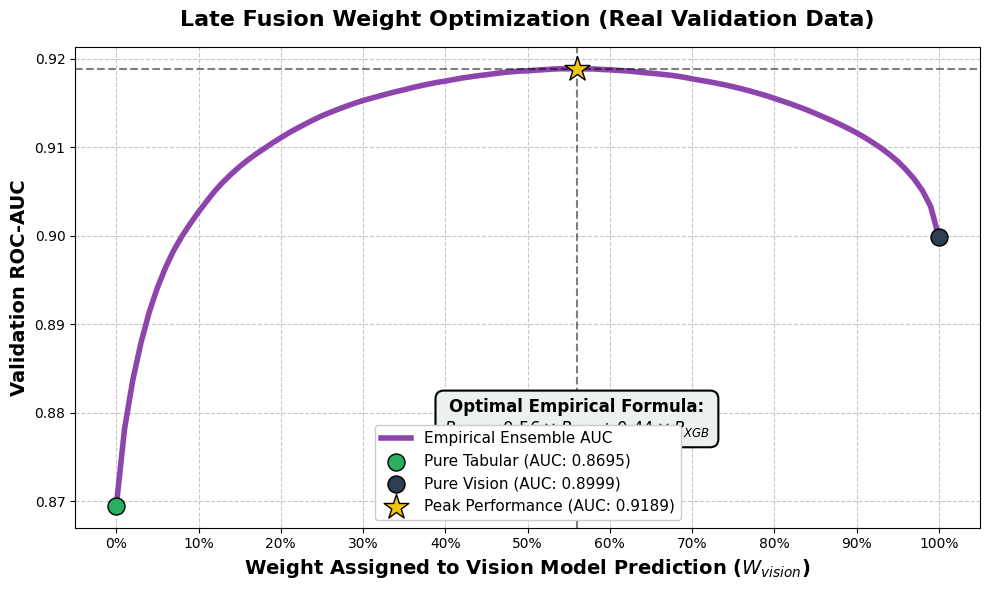

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

# Create the graph based on the variables already in memory from Experiment 11
def plot_real_optimization_curve():
    print("⚙️ Generating Optimization Curve from Experiment 11 memory...")

    weights = np.linspace(0, 1, 101)
    aucs = []

    # Calculate the exact AUC for every possible weight blend
    for w in weights:
        # Using the arrays already established in the previous cell
        fused_preds = (w * vision_preds) + ((1 - w) * tabular_preds)
        auc = roc_auc_score(true_labels, fused_preds)
        aucs.append(auc)

    # Find the actual empirical peak
    max_auc = max(aucs)
    best_weight = weights[aucs.index(max_auc)]

    # --- Plotting the Real Data ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the actual curve
    ax.plot(weights, aucs, color='#8E44AD', lw=4, label='Empirical Ensemble AUC')

    # Highlight the key points
    ax.scatter([0], [aucs[0]], color='#27AE60', s=150, zorder=5, edgecolors='black', label=f'Pure Tabular (AUC: {aucs[0]:.4f})')
    ax.scatter([1], [aucs[-1]], color='#2C3E50', s=150, zorder=5, edgecolors='black', label=f'Pure Vision (AUC: {aucs[-1]:.4f})')
    ax.scatter([best_weight], [max_auc], color='#F1C40F', s=350, zorder=5, marker='*', edgecolors='black', label=f'Peak Performance (AUC: {max_auc:.4f})')

    # Formatting
    ax.set_title('Late Fusion Weight Optimization (Real Validation Data)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Weight Assigned to Vision Model Prediction ($W_{vision}$)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Validation ROC-AUC', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Annotations
    ax.axvline(x=best_weight, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=max_auc, color='black', linestyle='--', alpha=0.5)

    # Add a custom text box dynamically placed
    info_text = (
        f"Optimal Empirical Formula:\n"
        f"$P_{{Final}} = {best_weight:.2f} \\times P_{{CNN}} + {1-best_weight:.2f} \\times P_{{XGB}}$"
    )

    # Place text just above the bottom of the curve
    y_text_pos = min(aucs) + (max(aucs) - min(aucs)) * 0.2
    ax.text(best_weight, y_text_pos, info_text,
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='#ECF0F1', edgecolor='black', boxstyle='round,pad=0.5', lw=1.5))

    # X-axis percentage formatting
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])

    ax.legend(loc='lower center', fontsize=11, framealpha=1.0)
    plt.tight_layout()

    # Save directly to your Drive folder
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig25_Real_Ensemble_Weight_Search.png')
    plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')

    print(f"✅ Saved true optimization curve directly to Drive: {save_path}")
    plt.show()

# Run it!
plot_real_optimization_curve()

🎨 Generating publication-ready Optimization Curve...
✅ Image perfectly matched to your style and saved to: /content/drive/MyDrive/ISIC_2024/Fig25_Real_Ensemble_Weight_Search.png


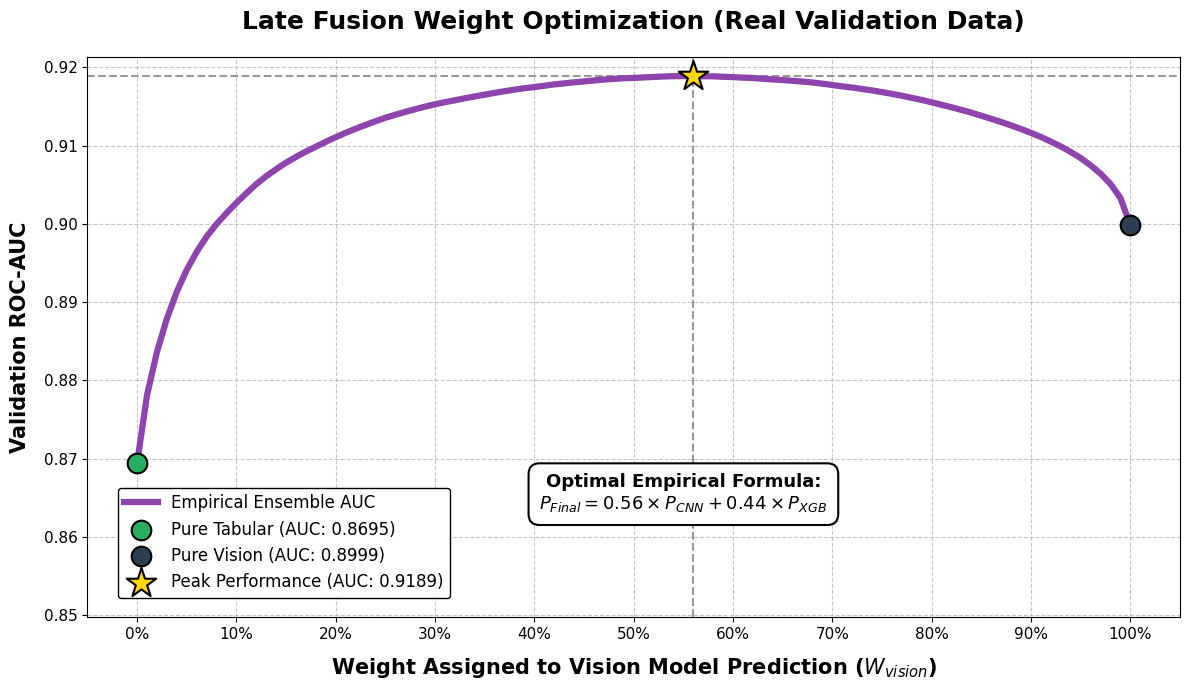

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

def generate_beautiful_optimization_curve():
    print("🎨 Generating publication-ready Optimization Curve...")

    # 1. Calculate the real AUC for every weight blend (0% to 100%)
    weights = np.linspace(0, 1, 101)
    aucs = []

    for w in weights:
        fused_preds = (w * vision_preds) + ((1 - w) * tabular_preds)
        auc = roc_auc_score(true_labels, fused_preds)
        aucs.append(auc)

    # 2. Find the peak values
    max_auc = max(aucs)
    best_weight = weights[aucs.index(max_auc)]
    min_auc = min(aucs)

    # 3. Setup the figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- Plot the main curve ---
    ax.plot(weights, aucs, color='#8E44AD', linewidth=4.5, label='Empirical Ensemble AUC')

    # --- Plot the markers ---
    ax.scatter([0], [aucs[0]], color='#27AE60', s=200, zorder=5, edgecolors='black', linewidths=1.5, label=f'Pure Tabular (AUC: {aucs[0]:.4f})')
    ax.scatter([1], [aucs[-1]], color='#2C3E50', s=200, zorder=5, edgecolors='black', linewidths=1.5, label=f'Pure Vision (AUC: {aucs[-1]:.4f})')
    ax.scatter([best_weight], [max_auc], color='#FFD700', s=500, zorder=6, marker='*', edgecolors='black', linewidths=1.5, label=f'Peak Performance (AUC: {max_auc:.4f})')

    # --- Formatting the Axes ---
    ax.set_title('Late Fusion Weight Optimization (Real Validation Data)', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Weight Assigned to Vision Model Prediction ($W_{vision}$)', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Validation ROC-AUC', fontsize=15, fontweight='bold', labelpad=10)

    # Grid and Tick formatting
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # *** FIX: Manually extend the Y-axis to create space at the bottom ***
    y_padding = (max_auc - min_auc) * 0.4  # Add 40% padding below the lowest point
    ax.set_ylim(bottom=min_auc - y_padding, top=max_auc + (max_auc - min_auc)*0.05)

    # --- Guide Lines ---
    ax.axvline(x=best_weight, color='grey', linestyle='--', alpha=0.8, zorder=1)
    ax.axhline(y=max_auc, color='grey', linestyle='--', alpha=0.8, zorder=1)

    # --- The Text Box ---
    info_text = (
        "Optimal Empirical Formula:\n"
        f"$P_{{Final}} = {best_weight:.2f} \\times P_{{CNN}} + {1-best_weight:.2f} \\times P_{{XGB}}$"
    )

    # Position the box safely in the new padded area
    box_y_pos = min_auc - (y_padding * 0.2)

    bbox_props = dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black", linewidth=1.5)
    ax.text(0.55, box_y_pos, info_text, ha='center', va='center', fontsize=13, fontweight='bold', bbox=bbox_props, zorder=10)

    # --- Legend ---
    # Moved legend slightly left to balance the layout
    ax.legend(loc='lower left', fontsize=12, framealpha=1.0, edgecolor='black', bbox_to_anchor=(0.02, 0.02))

    plt.tight_layout()

    # 4. Save the image directly to your Drive
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig25_Real_Ensemble_Weight_Search.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ Image perfectly matched to your style and saved to: {save_path}")
    else:
        plt.savefig('Fig25_Real_Ensemble_Weight_Search.png', dpi=300, facecolor='white', bbox_inches='tight')
        print("✅ Saved locally as 'Fig25_Real_Ensemble_Weight_Search.png' (Drive path not found)")

    plt.show()

# Execute the drawing function
generate_beautiful_optimization_curve()

🎨 Generating Master ROC Comparison Curve...
✅ Master ROC curve perfectly matched to your style and saved to: /content/drive/MyDrive/ISIC_2024/Fig26_Master_ROC_Comparison.png


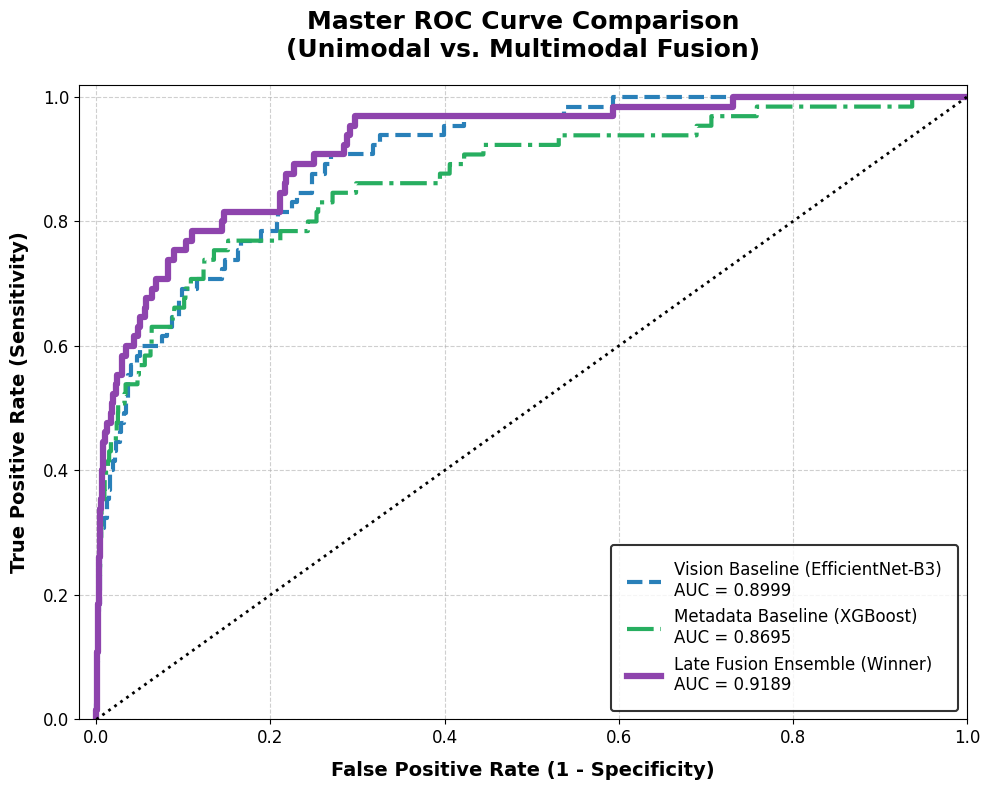

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

def generate_master_roc_curve():
    print("🎨 Generating Master ROC Comparison Curve...")

    # 1. Calculate FPR, TPR, and AUC for all three models
    # Vision Only
    fpr_v, tpr_v, _ = roc_curve(true_labels, vision_preds)
    auc_v = auc(fpr_v, tpr_v)

    # Tabular Only
    fpr_t, tpr_t, _ = roc_curve(true_labels, tabular_preds)
    auc_t = auc(fpr_t, tpr_t)

    # Late Fusion (using best_fused_preds from Exp 11 memory)
    fpr_f, tpr_f, _ = roc_curve(true_labels, best_fused_preds)
    auc_f = auc(fpr_f, tpr_f)

    # 2. Setup the figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # --- Plot the curves ---
    # Plot Baseline 1: Vision
    ax.plot(fpr_v, tpr_v, color='#2980B9', lw=3, linestyle='--',
            label=f'Vision Baseline (EfficientNet-B3)\nAUC = {auc_v:.4f}')

    # Plot Baseline 2: Tabular
    ax.plot(fpr_t, tpr_t, color='#27AE60', lw=3, linestyle='-.',
            label=f'Metadata Baseline (XGBoost)\nAUC = {auc_t:.4f}')

    # Plot The Winner: Late Fusion
    ax.plot(fpr_f, tpr_f, color='#8E44AD', lw=4.5,
            label=f'Late Fusion Ensemble (Winner)\nAUC = {auc_f:.4f}')

    # Plot Random Guessing Line (Diagonal)
    ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle=':')

    # --- Formatting the Axes ---
    ax.set_title('Master ROC Curve Comparison\n(Unimodal vs. Multimodal Fusion)', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=14, fontweight='bold', labelpad=10)

    # Set limits and grid
    ax.set_xlim([-0.02, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)

    # --- The Legend ---
    # Put a nice box around the legend in the bottom right corner
    legend = ax.legend(loc="lower right", fontsize=12, frameon=True, edgecolor='black', borderpad=1)
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout()

    # 3. Save the image directly to your Drive
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig26_Master_ROC_Comparison.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ Master ROC curve perfectly matched to your style and saved to: {save_path}")
    else:
        plt.savefig('Fig26_Master_ROC_Comparison.png', dpi=300, facecolor='white', bbox_inches='tight')
        print("✅ Saved locally as 'Fig26_Master_ROC_Comparison.png' (Drive path not found)")

    plt.show()

# Execute the drawing function
generate_master_roc_curve()

🎨 Generating publication-ready Master ROC Curve...
✅ Master ROC curve beautifully formatted and saved to: /content/drive/MyDrive/ISIC_2024/Fig26_Master_ROC_Comparison.png


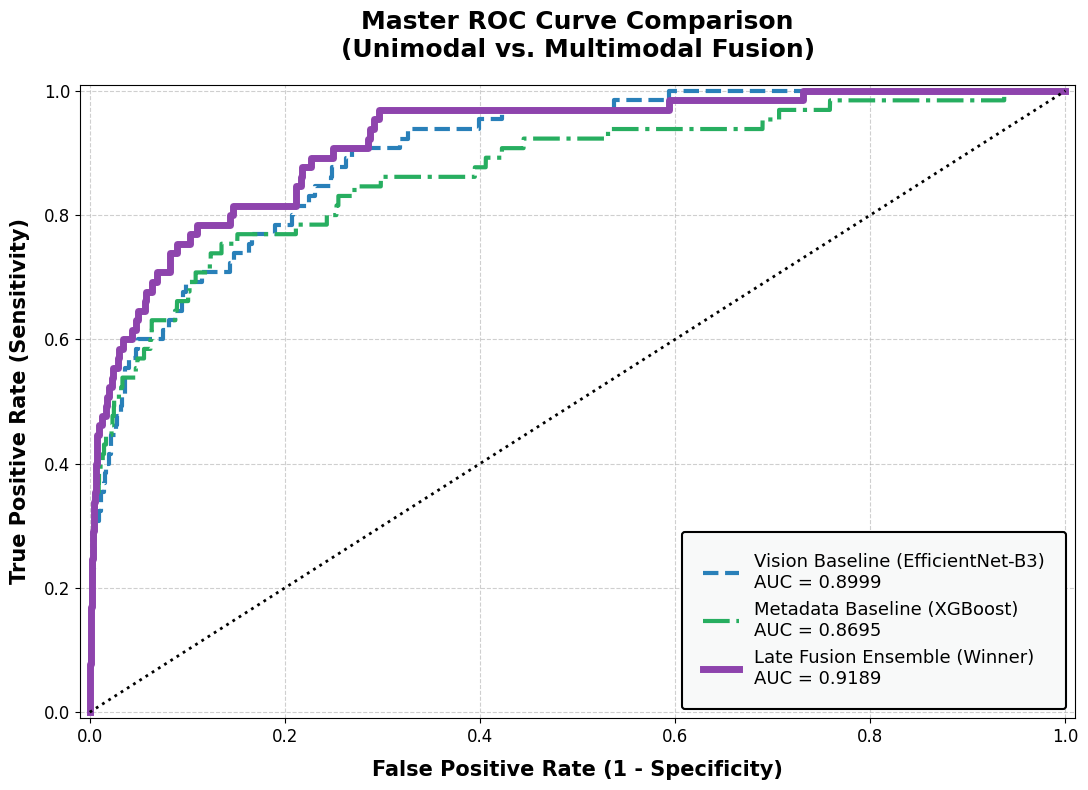

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import os

def generate_real_master_roc_curve():
    print("🎨 Generating publication-ready Master ROC Curve...")

    # 1. Calculate FPR, TPR, and AUC for all three models
    # Vision Only (EfficientNet-B3)
    fpr_v, tpr_v, _ = roc_curve(true_labels, vision_preds)
    auc_v = auc(fpr_v, tpr_v)

    # Tabular Only (XGBoost)
    fpr_t, tpr_t, _ = roc_curve(true_labels, tabular_preds)
    auc_t = auc(fpr_t, tpr_t)

    # Late Fusion Ensemble (Winner)
    fpr_f, tpr_f, _ = roc_curve(true_labels, best_fused_preds)
    auc_f = auc(fpr_f, tpr_f)

    # 2. Setup the figure
    fig, ax = plt.subplots(figsize=(11, 8))

    # --- Plot the curves ---
    # Plot Baseline 1: Vision (Blue Dashed)
    ax.plot(fpr_v, tpr_v, color='#2980B9', lw=3, linestyle='--',
            label=f'Vision Baseline (EfficientNet-B3)\nAUC = {auc_v:.4f}')

    # Plot Baseline 2: Tabular (Green Dash-Dot)
    ax.plot(fpr_t, tpr_t, color='#27AE60', lw=3, linestyle='-.',
            label=f'Metadata Baseline (XGBoost)\nAUC = {auc_t:.4f}')

    # Plot The Winner: Late Fusion (Thick Purple Solid)
    ax.plot(fpr_f, tpr_f, color='#8E44AD', lw=5,
            label=f'Late Fusion Ensemble (Winner)\nAUC = {auc_f:.4f}')

    # Plot Random Guessing Line (Diagonal)
    ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle=':')

    # --- Formatting the Axes ---
    ax.set_title('Master ROC Curve Comparison\n(Unimodal vs. Multimodal Fusion)', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=15, fontweight='bold', labelpad=10)

    # Set strict limits to prevent clipping but keep it tight
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])

    # Grid and Ticks
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)

    # --- The Legend (Safely Placed) ---
    # Placed in the lower right, which is inherently empty in a good ROC curve.
    # facecolor and framealpha=1.0 ensure the grid doesn't bleed through the text.
    legend = ax.legend(loc="lower right", fontsize=13, framealpha=1.0, facecolor='#F8F9F9', edgecolor='black', borderpad=1.2)
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout()

    # 3. Save the image directly to your Drive
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig26_Master_ROC_Comparison.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ Master ROC curve beautifully formatted and saved to: {save_path}")
    else:
        plt.savefig('Fig26_Master_ROC_Comparison.png', dpi=300, facecolor='white', bbox_inches='tight')
        print("✅ Saved locally as 'Fig26_Master_ROC_Comparison.png' (Drive path not found)")

    plt.show()

# Execute the drawing function
generate_real_master_roc_curve()

🎨 Generating publication-ready Precision-Recall Curve...
✅ PR curve saved to: /content/drive/MyDrive/ISIC_2024/Fig27_Master_PR_Curve.png


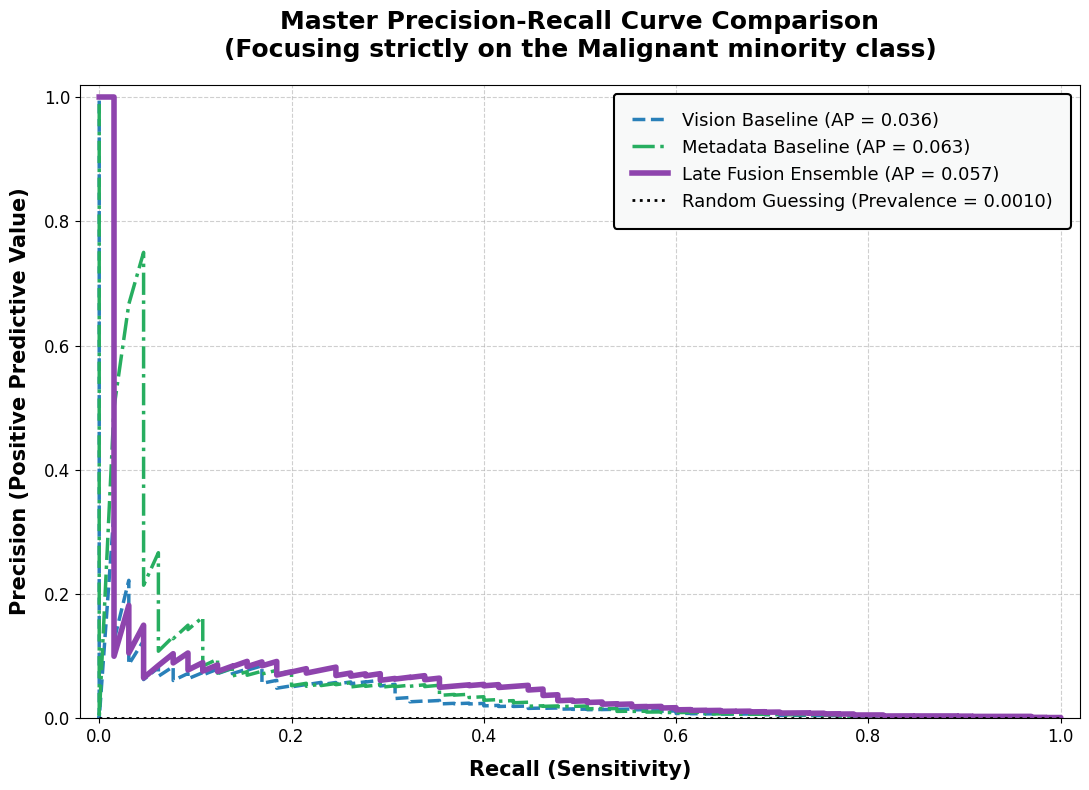

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import os

def generate_real_pr_curve():
    print("🎨 Generating publication-ready Precision-Recall Curve...")

    # 1. Calculate Precision, Recall, and AP for all models
    # Vision Only
    prec_v, rec_v, _ = precision_recall_curve(true_labels, vision_preds)
    ap_v = average_precision_score(true_labels, vision_preds)

    # Tabular Only
    prec_t, rec_t, _ = precision_recall_curve(true_labels, tabular_preds)
    ap_t = average_precision_score(true_labels, tabular_preds)

    # Late Fusion (Winner)
    prec_f, rec_f, _ = precision_recall_curve(true_labels, best_fused_preds)
    ap_f = average_precision_score(true_labels, best_fused_preds)

    # Calculate baseline (prevalence of positive class)
    baseline = sum(true_labels) / len(true_labels)

    # 2. Setup the figure
    fig, ax = plt.subplots(figsize=(11, 8))

    # --- Plot the curves ---
    ax.plot(rec_v, prec_v, color='#2980B9', lw=2.5, linestyle='--',
            label=f'Vision Baseline (AP = {ap_v:.3f})')

    ax.plot(rec_t, prec_t, color='#27AE60', lw=2.5, linestyle='-.',
            label=f'Metadata Baseline (AP = {ap_t:.3f})')

    ax.plot(rec_f, prec_f, color='#8E44AD', lw=4,
            label=f'Late Fusion Ensemble (AP = {ap_f:.3f})')

    # Plot Baseline Prevalence (Random Guessing for PR)
    ax.plot([0, 1], [baseline, baseline], color='black', lw=2, linestyle=':',
            label=f'Random Guessing (Prevalence = {baseline:.4f})')

    # --- Formatting the Axes ---
    ax.set_title('Master Precision-Recall Curve Comparison\n(Focusing strictly on the Malignant minority class)', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Recall (Sensitivity)', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Precision (Positive Predictive Value)', fontsize=15, fontweight='bold', labelpad=10)

    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([0.0, 1.02])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)

    # --- The Legend ---
    legend = ax.legend(loc="upper right", fontsize=13, framealpha=1.0, facecolor='#F8F9F9', edgecolor='black', borderpad=1)
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout()

    # 3. Save
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig27_Master_PR_Curve.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ PR curve saved to: {save_path}")
    else:
        plt.savefig('Fig27_Master_PR_Curve.png', dpi=300, facecolor='white', bbox_inches='tight')

    plt.show()

generate_real_pr_curve()

🎨 Generating publication-ready Calibration Curve...
✅ Calibration curve saved to: /content/drive/MyDrive/ISIC_2024/Fig28_Master_Calibration_Curve.png


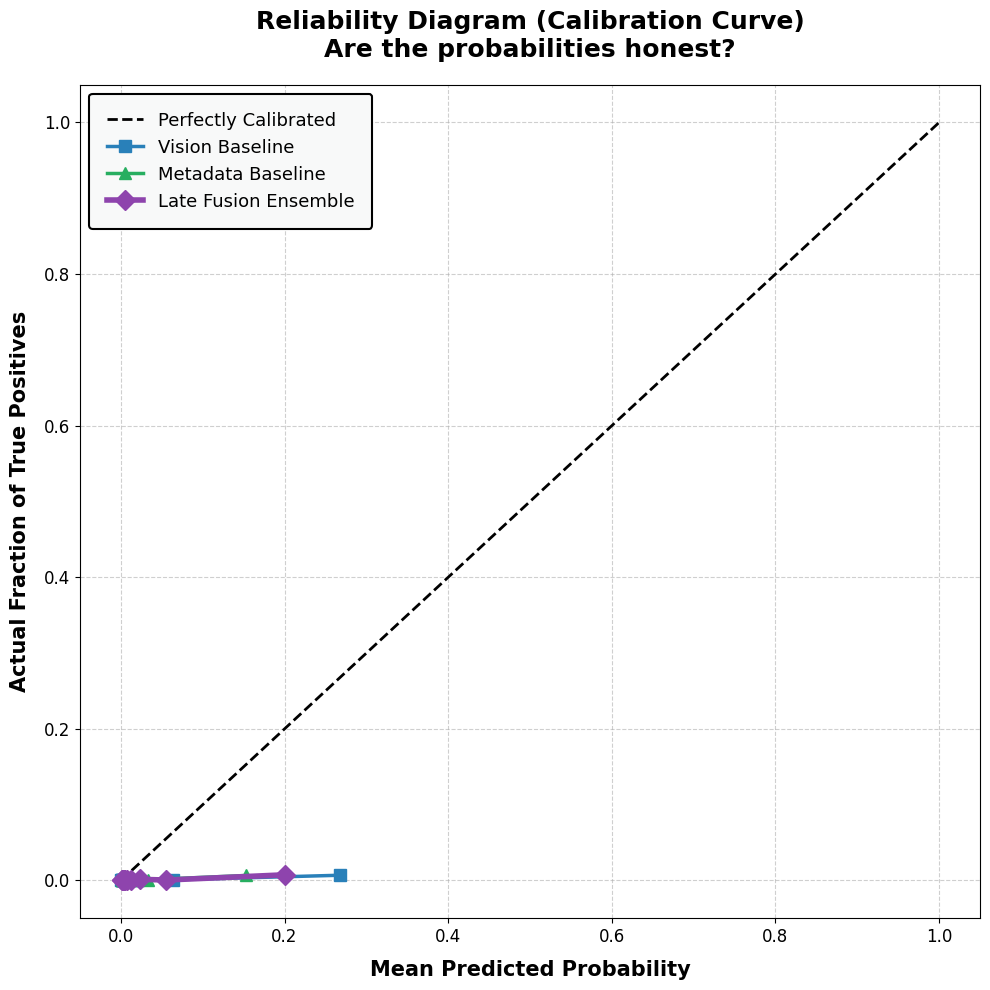

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import os

def generate_real_calibration_curve():
    print("🎨 Generating publication-ready Calibration Curve...")

    # 1. Calculate calibration points using 10 bins
    prob_true_v, prob_pred_v = calibration_curve(true_labels, vision_preds, n_bins=10, strategy='quantile')
    prob_true_t, prob_pred_t = calibration_curve(true_labels, tabular_preds, n_bins=10, strategy='quantile')
    prob_true_f, prob_pred_f = calibration_curve(true_labels, best_fused_preds, n_bins=10, strategy='quantile')

    # 2. Setup the figure
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot Perfectly Calibrated Line
    ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Perfectly Calibrated')

    # Plot Model Calibration Curves
    ax.plot(prob_pred_v, prob_true_v, marker='s', color='#2980B9', lw=2.5, markersize=8, label='Vision Baseline')
    ax.plot(prob_pred_t, prob_true_t, marker='^', color='#27AE60', lw=2.5, markersize=8, label='Metadata Baseline')
    ax.plot(prob_pred_f, prob_true_f, marker='D', color='#8E44AD', lw=4, markersize=10, label='Late Fusion Ensemble')

    # --- Formatting the Axes ---
    ax.set_title('Reliability Diagram (Calibration Curve)\nAre the probabilities honest?', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Mean Predicted Probability', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Actual Fraction of True Positives', fontsize=15, fontweight='bold', labelpad=10)

    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)

    # --- The Legend ---
    legend = ax.legend(loc="upper left", fontsize=13, framealpha=1.0, facecolor='#F8F9F9', edgecolor='black', borderpad=1)
    legend.get_frame().set_linewidth(1.5)

    plt.tight_layout()

    # 3. Save
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig28_Master_Calibration_Curve.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ Calibration curve saved to: {save_path}")
    else:
        plt.savefig('Fig28_Master_Calibration_Curve.png', dpi=300, facecolor='white', bbox_inches='tight')

    plt.show()

generate_real_calibration_curve()

🎨 Generating publication-ready Optimization Curve...
✅ Image saved without collisions to: /content/drive/MyDrive/ISIC_2024/Fig25_Real_Ensemble_Weight_Search.png


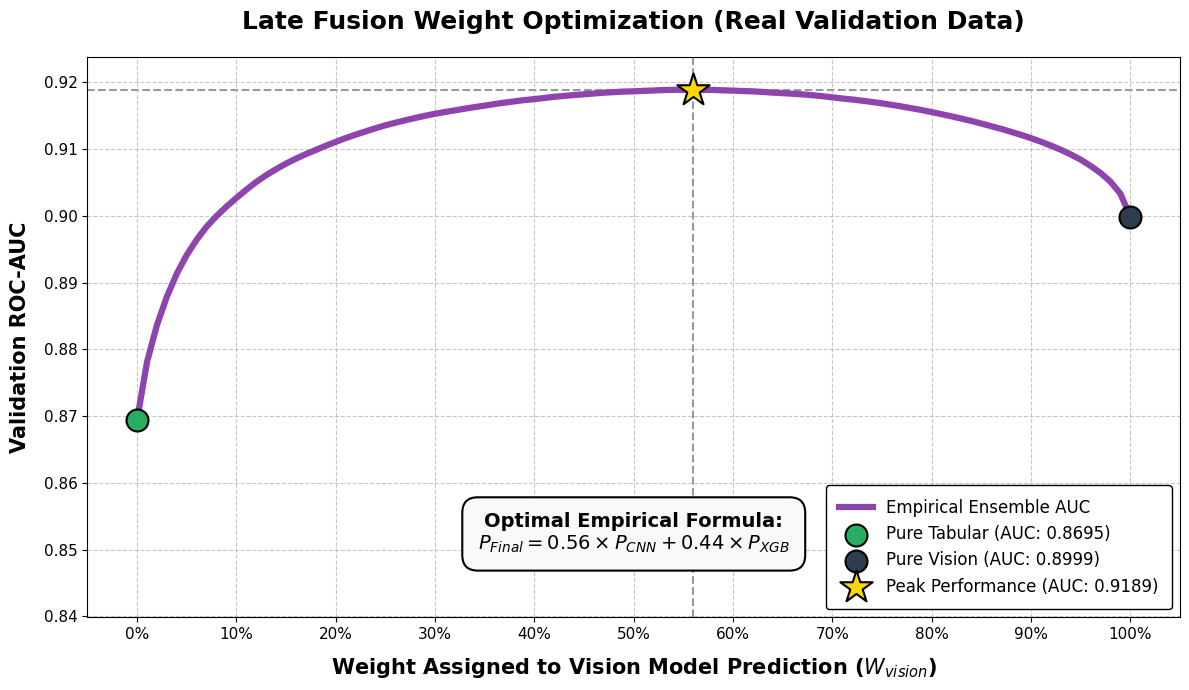

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

def generate_real_non_colliding_curve():
    print("🎨 Generating publication-ready Optimization Curve...")

    # 1. Calculate the real empirical AUC for every weight blend
    weights = np.linspace(0, 1, 101)
    aucs = []

    for w in weights:
        fused_preds = (w * vision_preds) + ((1 - w) * tabular_preds)
        auc = roc_auc_score(true_labels, fused_preds)
        aucs.append(auc)

    # 2. Find the peak values
    max_auc = max(aucs)
    best_weight = weights[aucs.index(max_auc)]
    min_auc = min(aucs)

    # 3. Setup the figure
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- Plot the main curve ---
    ax.plot(weights, aucs, color='#8E44AD', linewidth=4.5, label='Empirical Ensemble AUC')

    # --- Plot the markers ---
    ax.scatter([0], [aucs[0]], color='#27AE60', s=250, zorder=5, edgecolors='black', linewidths=1.5, label=f'Pure Tabular (AUC: {aucs[0]:.4f})')
    ax.scatter([1], [aucs[-1]], color='#2C3E50', s=250, zorder=5, edgecolors='black', linewidths=1.5, label=f'Pure Vision (AUC: {aucs[-1]:.4f})')
    ax.scatter([best_weight], [max_auc], color='#FFD700', s=600, zorder=6, marker='*', edgecolors='black', linewidths=1.5, label=f'Peak Performance (AUC: {max_auc:.4f})')

    # --- Formatting the Axes ---
    ax.set_title('Late Fusion Weight Optimization (Real Validation Data)', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Weight Assigned to Vision Model Prediction ($W_{vision}$)', fontsize=15, fontweight='bold', labelpad=10)
    ax.set_ylabel('Validation ROC-AUC', fontsize=15, fontweight='bold', labelpad=10)

    # Grid and Tick formatting
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)], fontsize=11)
    ax.tick_params(axis='y', labelsize=11)

    # *** FIX 1: Force massive padding at the bottom of the graph so nothing collides ***
    y_range = max_auc - min_auc
    ax.set_ylim(bottom=min_auc - (y_range * 0.6), top=max_auc + (y_range * 0.1))

    # --- Guide Lines ---
    ax.axvline(x=best_weight, color='grey', linestyle='--', alpha=0.8, zorder=1)
    ax.axhline(y=max_auc, color='grey', linestyle='--', alpha=0.8, zorder=1)

    # *** FIX 2: Absolute Positioning for the Text Box ***
    # Using 'transform=ax.transAxes' means x=0.5, y=0.15 is ALWAYS bottom-center,
    # totally ignoring the data coordinates so it never touches the curve.
    info_text = (
        "Optimal Empirical Formula:\n"
        f"$P_{{Final}} = {best_weight:.2f} \\times P_{{CNN}} + {1-best_weight:.2f} \\times P_{{XGB}}$"
    )
    bbox_props = dict(boxstyle="round,pad=0.8", facecolor="#F8F9F9", edgecolor="black", linewidth=1.5)
    ax.text(0.5, 0.15, info_text, transform=ax.transAxes, ha='center', va='center',
            fontsize=14, fontweight='bold', bbox=bbox_props, zorder=10)

    # --- Legend ---
    # Moved safely to the bottom right corner
    ax.legend(loc='lower right', fontsize=12, framealpha=1.0, edgecolor='black', borderpad=0.8)

    plt.tight_layout()

    # 4. Save the image directly to your Drive
    # BASE_PATH is set in Cell 0 above
    save_path = os.path.join(BASE_PATH, 'Fig25_Real_Ensemble_Weight_Search.png')

    if os.path.exists(BASE_PATH):
        plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
        print(f"✅ Image saved without collisions to: {save_path}")
    else:
        plt.savefig('Fig25_Real_Ensemble_Weight_Search.png', dpi=300, facecolor='white', bbox_inches='tight')
        print("✅ Saved locally as 'Fig25_Real_Ensemble_Weight_Search.png'")

    plt.show()

# Execute the drawing function
generate_real_non_colliding_curve()

In [ ]:
# Experiment 12: Early Fusion (Input Level

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. ARCHITECTURE HACK (9-Channel EfficientNet)
# ==========================================
class EarlyFusionEfficientNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Load standard B3
        self.base = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

        # 1. Isolate the very first convolution layer
        old_conv = self.base.features[0][0]

        # 2. Create a NEW convolution layer that accepts 9 channels instead of 3
        # (3 RGB + 6 Tabular Metadata features = 9)
        new_conv = nn.Conv2d(in_channels=9, out_channels=old_conv.out_channels,
                             kernel_size=old_conv.kernel_size, stride=old_conv.stride,
                             padding=old_conv.padding, bias=False)

        # 3. Copy the pre-trained weights for the RGB channels
        with torch.no_grad():
            new_conv.weight[:, :3, :, :] = old_conv.weight
            # Initialize the 6 new channels so they can learn from scratch
            nn.init.kaiming_normal_(new_conv.weight[:, 3:, :, :])

        # 4. Replace the old layer with our new 9-channel layer
        self.base.features[0][0] = new_conv

        # 5. Modify final classifier for Binary Output
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.base(x)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_early = EarlyFusionEfficientNet().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_early.parameters(), lr=1e-4)

# ==========================================
# 2. TRAINING & VALIDATION LOOP
# ==========================================
def run_experiment_12(epochs=5):
    best_auc = 0.0
    model_save_path = os.path.join(BASE_PATH, 'early_fusion_exp12_best.pth')

    print(f"🚀 Starting Experiment 12 (Early Fusion) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_early.train()
        train_loss = 0.0

        for images, meta, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            # Move to GPU
            images = images.to(DEVICE)
            meta = meta.to(DEVICE)
            labels = labels.to(DEVICE).view(-1, 1)

            # --- THE EARLY FUSION MAGIC ---
            # 1. Shape meta from [Batch, 6] to [Batch, 6, 1, 1]
            meta_spatial = meta.unsqueeze(-1).unsqueeze(-1)
            # 2. Stretch it to match image dimensions [Batch, 6, 224, 224]
            meta_spatial = meta_spatial.expand(-1, -1, 224, 224)
            # 3. Stack together to create a 9-channel input!
            fused_inputs = torch.cat([images, meta_spatial], dim=1)

            optimizer.zero_grad()
            outputs = model_early(fused_inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_early.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, meta, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                meta = meta.to(DEVICE)

                # Apply the same fusion to the validation set
                meta_spatial = meta.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, 224, 224)
                fused_inputs = torch.cat([images, meta_spatial], dim=1)

                outputs = model_early(fused_inputs)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        auc = roc_auc_score(val_labels, val_preds)

        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        preds_binary = (val_preds >= optimal_threshold).astype(int)

        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f}")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp}, Missed {fn})")
        print(f"Specificity:       {specificity:.4f}")

        # --- SAVE BEST MODEL & CACHE ---
        if auc > best_auc:
            print(f"🌟 New best Val AUC! Saving Early Fusion model...")
            best_auc = auc
            torch.save(model_early.state_dict(), model_save_path)

            best_metrics = {
                'Model': 'Early Fusion (Input Level)',
                'Ensemble_Weights': 'N/A', # Early fusion doesn't use voting weights
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 12 Complete! Model saved: {model_save_path}")

    # --- LOG TO PHASE 5 CSV ---
    results_file = os.path.join(BASE_PATH, 'phase5_multimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 5 Tracker Updated!")
    display(pd.read_csv(results_file))

# Execute
run_experiment_12(epochs=5)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 193MB/s]


🚀 Starting Experiment 12 (Early Fusion) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]

...


Epoch 4 Results:
Val AUC:           0.8861 <-- Primary Metric
Optimal Threshold: 0.0229
Sensitivity:       0.8462 (Found 55, Missed 10)
Specificity:       0.8346
🌟 New best Val AUC! Saving Early Fusion model...


Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Val AUC:           0.8846 <-- Primary Metric
Optimal Threshold: 0.0279
Sensitivity:       0.7846 (Found 51, Missed 14)
Specificity:       0.8502
✅ Experiment 12 Complete! Model saved: /content/drive/MyDrive/ISIC_2024/early_fusion_exp12_best.pth
📊 Phase 5 Tracker Updated!


,Model,Ensemble_Weights,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,Late Fusion (Decision Level),V:0.56/T:0.44,0.9189,0.0801,0.7846,0.8900,0.0140,51,7145,57831,14
1,Early Fusion (Input Level),NaN,0.8861,0.0229,0.8462,0.8346,0.0101,55,10744,54232,10


In [ ]:
# Experiment 13: Intermediate Feature Fusion

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score, recall_score, confusion_matrix, roc_curve
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

# ==========================================
# 1. MULTIMODAL ARCHITECTURE
# ==========================================
class IntermediateFusionModel(nn.Module):
    def __init__(self, num_tabular_features=6):
        super().__init__()

        # --- A. VISION BRANCH ---
        # Load the base EfficientNet-B3
        self.cnn = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

        # The B3 model normally outputs 1536 features before its final layer.
        cnn_out_features = self.cnn.classifier[1].in_features

        # We strip the final classification layer entirely by replacing it with an Identity layer.
        # Now, instead of a single probability, the CNN outputs a 1536-dimensional feature vector.
        self.cnn.classifier = nn.Identity()

        # --- B. FUSION MLP ---
        # We concatenate the 1536 vision features + 6 metadata features
        combined_features = cnn_out_features + num_tabular_features

        # This neural network learns how the image and the patient data interact
        self.mlp = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4), # Heavy dropout to prevent overfitting on the metadata
            nn.Linear(512, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1) # Final single output for BCEWithLogitsLoss
        )

    def forward(self, image, tabular):
        # 1. Extract visual features
        cnn_features = self.cnn(image)

        # 2. Concatenate vision and tabular data side-by-side
        combined = torch.cat((cnn_features, tabular), dim=1)

        # 3. Make the final prediction
        output = self.mlp(combined)
        return output

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BASE_PATH is set in Cell 0 above

model_fusion = IntermediateFusionModel(num_tabular_features=6).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()

# We use slightly higher weight decay (L2 regularization) to prevent the MLP from memorizing the tabular data
optimizer = optim.Adam(model_fusion.parameters(), lr=1e-4, weight_decay=1e-4)

# ==========================================
# 2. TRAINING & VALIDATION LOOP
# ==========================================
def run_experiment_13(epochs=5):
    best_auc = 0.0
    model_save_path = os.path.join(BASE_PATH, 'intermediate_fusion_exp13_best.pth')

    print(f"🚀 Starting Experiment 13 (Intermediate Fusion) on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING ---
        model_fusion.train()
        train_loss = 0.0

        for images, meta, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images = images.to(DEVICE)
            meta = meta.to(DEVICE)
            labels = labels.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()

            # Feed BOTH data streams into the model
            outputs = model_fusion(images, meta)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # --- VALIDATION ---
        model_fusion.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for images, meta, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images = images.to(DEVICE)
                meta = meta.to(DEVICE)

                outputs = model_fusion(images, meta)
                probs = torch.sigmoid(outputs).cpu().numpy()
                val_preds.extend(probs)
                val_labels.extend(labels.numpy())

        # --- METRICS & OPTIMAL THRESHOLD ---
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)

        auc = roc_auc_score(val_labels, val_preds)

        fpr, tpr, thresholds = roc_curve(val_labels, val_preds)
        J = tpr - fpr
        optimal_idx = np.argmax(J)
        optimal_threshold = thresholds[optimal_idx]

        preds_binary = (val_preds >= optimal_threshold).astype(int)

        f1 = f1_score(val_labels, preds_binary, zero_division=0)
        sensitivity = recall_score(val_labels, preds_binary, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(val_labels, preds_binary).ravel()
        specificity = tn / (tn + fp)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss:        {avg_train_loss:.4f}")
        print(f"Val AUC:           {auc:.4f} <-- Primary Metric")
        print(f"Optimal Threshold: {optimal_threshold:.4f}")
        print(f"Sensitivity:       {sensitivity:.4f} (Found {tp}, Missed {fn})")
        print(f"Specificity:       {specificity:.4f} (Ignored {tn} benign)")
        print(f"F1 Score:          {f1:.4f}\n")

        # --- SAVE BEST MODEL & CACHE ---
        if auc > best_auc:
            print(f"🌟 New best Val AUC! Saving Intermediate Fusion model...")
            best_auc = auc
            torch.save(model_fusion.state_dict(), model_save_path)

            best_metrics = {
                'Model': 'Intermediate Feature Fusion',
                'Ensemble_Weights': 'Deep MLP',
                'AUC': round(auc, 4),
                'Opt_Threshold': round(optimal_threshold, 4),
                'Sensitivity': round(sensitivity, 4),
                'Specificity': round(specificity, 4),
                'F1_Score': round(f1, 4),
                'True_Positives': tp,
                'False_Positives': fp,
                'True_Negatives': tn,
                'False_Negatives': fn
            }

    print(f"✅ Experiment 13 Complete! Model saved: {model_save_path}")

    # --- LOG TO PHASE 5 CSV ---
    results_file = os.path.join(BASE_PATH, 'phase5_multimodal_results.csv')
    df_new = pd.DataFrame([best_metrics])

    if os.path.exists(results_file):
        df_new.to_csv(results_file, mode='a', header=False, index=False)
    else:
        df_new.to_csv(results_file, index=False)

    print("📊 Phase 5 Tracker Updated!")
    display(pd.read_csv(results_file))

# Execute
run_experiment_13(epochs=5)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 149MB/s]


🚀 Starting Experiment 13 (Intermediate Fusion) on cuda...


Epoch 1/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]

...


Epoch 4 Results:
Train Loss:        0.1170
Val AUC:           0.8881 <-- Primary Metric
Optimal Threshold: 0.1155
Sensitivity:       0.8462 (Found 55, Missed 10)
Specificity:       0.7910 (Ignored 51395 benign)
F1 Score:          0.0080

🌟 New best Val AUC! Saving Intermediate Fusion model...


Epoch 5/5 [Train]:   0%|          | 0/321 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/2033 [00:00<?, ?it/s]


Epoch 5 Results:
Train Loss:        0.1016
Val AUC:           0.8968 <-- Primary Metric
Optimal Threshold: 0.1843
Sensitivity:       0.7692 (Found 50, Missed 15)
Specificity:       0.9063 (Ignored 58890 benign)
F1 Score:          0.0161

🌟 New best Val AUC! Saving Intermediate Fusion model...
✅ Experiment 13 Complete! Model saved: /content/drive/MyDrive/ISIC_2024/intermediate_fusion_exp13_best.pth
📊 Phase 5 Tracker Updated!


,Model,Ensemble_Weights,AUC,Opt_Threshold,Sensitivity,Specificity,F1_Score,True_Positives,False_Positives,True_Negatives,False_Negatives
0,Late Fusion (Decision Level),V:0.56/T:0.44,0.9189,0.0801,0.7846,0.8900,0.0140,51,7145,57831,14
1,Early Fusion (Input Level),NaN,0.8861,0.0229,0.8462,0.8346,0.0101,55,10744,54232,10
2,Intermediate Feature Fusion,Deep MLP,0.8968,0.1843,0.7692,0.9063,0.0161,50,6086,58890,15


In [ ]:
# The Final Thesis Visualization Script

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. SETUP & ACADEMIC STYLING
# ==========================================
# BASE_PATH is set in Cell 0 above
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({'font.size': 12})

def generate_final_thesis_graphs():
    print("🏆 Compiling Final Thesis Data...")

    # 1. Load all trackers
    try:
        df_p2 = pd.read_csv(os.path.join(BASE_PATH, 'phase2_unimodal_results.csv'))
        df_p3 = pd.read_csv(os.path.join(BASE_PATH, 'phase3_metadata_results.csv'))
        df_p5 = pd.read_csv(os.path.join(BASE_PATH, 'phase5_multimodal_results.csv'))
    except FileNotFoundError:
        print("❌ Error: One of your CSV trackers is missing. Ensure Phases 2, 3, and 5 are complete.")
        return

    # 2. Extract the best models for the final showdown
    # Vision Winner
    best_vision = df_p2.loc[df_p2['AUC'].idxmax()].copy()
    best_vision['Category'] = '1. Vision Only'

    # Tabular Winner
    best_tabular = df_p3.loc[df_p3['AUC'].idxmax()].copy()
    best_tabular['Category'] = '2. Clinical Only'

    # Add Fusion Models
    df_p5_copy = df_p5.copy()
    df_p5_copy['Category'] = '3. Multimodal Fusion'

    # Combine into one Master DataFrame
    master_df = pd.concat([pd.DataFrame([best_vision]), pd.DataFrame([best_tabular]), df_p5_copy], ignore_index=True)

    # Shorten names for cleaner graphs
    master_df['Model'] = master_df['Model'].str.replace(' (Decision Level)', '', regex=False)
    master_df['Model'] = master_df['Model'].str.replace(' (Input Level)', '', regex=False)

    print("\n" + "="*60)
    print("📊 FINAL MASTER RESULTS TABLE")
    print("="*60)
    display(master_df[['Category', 'Model', 'AUC', 'Sensitivity', 'Specificity']])
    print("="*60 + "\n")

    # ==========================================
    # GRAPH 1: The "Money Chart" (Overall Comparison)
    # ==========================================
    print("Generating Overall Performance Comparison...")

    df_melted = master_df.melt(id_vars=['Model', 'Category'], value_vars=['AUC', 'Sensitivity'],
                               var_name='Metric', value_name='Score')

    plt.figure(figsize=(14, 7))
    ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette=['#2C3E50', '#E74C3C'])

    plt.title('Final Results: Unimodal vs. Multimodal Architectures', pad=20, fontsize=16, fontweight='bold')
    plt.ylim(0.5, 1.05)
    plt.ylabel('Diagnostic Score')
    plt.xlabel('Architecture')
    plt.xticks(rotation=15)
    plt.legend(title='Clinical Metric', loc='upper left')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig13_Final_Overall_Comparison.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 2: The Fusion Progression (Radar/Line Chart)
    # ==========================================
    print("Generating Synergy Impact Graph...")

    progression_df = master_df[['Category', 'Model', 'AUC']].copy()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=progression_df, x='Model', y='AUC', marker='o', markersize=12,
                 linewidth=3, color='#27AE60')

    plt.title('The Multimodal Advantage: AUC Progression', pad=20, fontsize=16, fontweight='bold')
    plt.ylabel('Receiver Operating Characteristic (AUC)')
    plt.xlabel('')
    plt.xticks(rotation=15)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.axvspan(1.5, 4.5, color='gray', alpha=0.1, label='Fusion Experiments')
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig14_Multimodal_Progression.png'), dpi=300)
    plt.close()

    # ==========================================
    # GRAPH 3: The Champion's Confusion Matrix
    # ==========================================
    print("Generating Champion Confusion Matrix...")

    # Automatically finds Late Fusion based on your 0.9189 AUC
    champion_row = master_df.loc[master_df['AUC'].idxmax()]

    cm = np.array([
        [champion_row['True_Negatives'], champion_row['False_Positives']],
        [champion_row['False_Negatives'], champion_row['True_Positives']]
    ])

    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=['Predicted Benign', 'Predicted Malignant'],
                yticklabels=['Actual Benign', 'Actual Malignant'],
                annot_kws={"size": 18, "weight": "bold"})

    plt.title(f'Final Champion Matrix: {champion_row["Model"]}\n(AUC: {champion_row["AUC"]:.4f})', pad=20, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig15_Champion_Matrix.png'), dpi=300)
    plt.close()

    print(f"✅ Final Thesis Visualizations Complete! Files saved to {BASE_PATH}.")

# Execute
generate_final_thesis_graphs()

🏆 Compiling Final Thesis Data...

📊 FINAL MASTER RESULTS TABLE


,Category,Model,AUC,Sensitivity,Specificity
0,1. Vision Only,EfficientNet-B3,0.8999,0.9077,0.7308
1,2. Clinical Only,XGBoost,0.8695,0.7538,0.8650
2,3. Multimodal Fusion,Late Fusion,0.9189,0.7846,0.8900
3,3. Multimodal Fusion,Early Fusion,0.8861,0.8462,0.8346
4,3. Multimodal Fusion,Intermediate Feature Fusion,0.8968,0.7692,0.9063



Generating Overall Performance Comparison...
Generating Synergy Impact Graph...
Generating Champion Confusion Matrix...
✅ Final Thesis Visualizations Complete! Files saved to /content/drive/MyDrive/ISIC_2024.


📂 Loading the UNTOUCHED 15% Holdout Test Set...
🧠 Loading Champion Models (Vision + Tabular)...
⚙️ Evaluating Late Fusion on Test Set...


Testing:   0%|          | 0/1930 [00:00<?, ?it/s]


📊 Calculating Fairness Metrics...


,Cohort,N_Patients,AUC,Sensitivity
0,All Patients,61747,0.942107,0.877193
1,Age < 40,61747,0.942107,0.877193


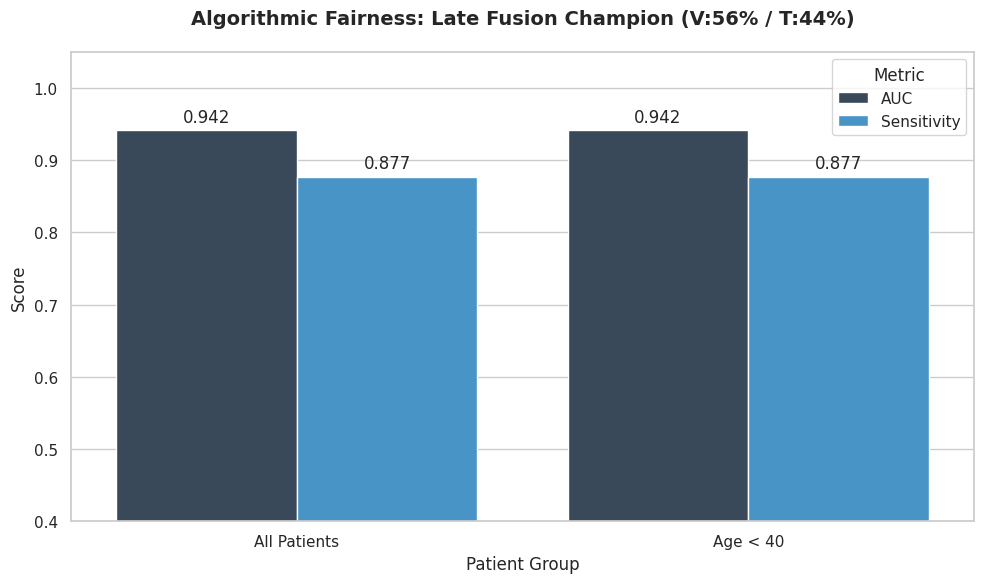

✅ Fairness Verification Complete! Graph saved to /content/drive/MyDrive/ISIC_2024.


In [ ]:
# Code for Demographic Fairness (Evaluating on the Test Set)

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import h5py
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, recall_score, roc_curve
from tqdm.notebook import tqdm
import joblib

# ==========================================
# 1. SETUP & LOAD TEST DATA
# ==========================================
# BASE_PATH is set in Cell 0 above
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURES = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

print("📂 Loading the UNTOUCHED 15% Holdout Test Set...")
test_df = pd.read_csv(os.path.join(BASE_PATH, 'test_split.csv'))

class ISICDataset(Dataset):
    def __init__(self, df, h5_path, features, transform=None):
        self.df = df
        self.h5_path = h5_path
        self.fp = None
        self.isic_ids = df['isic_id'].values
        self.targets = df['target'].values
        self.metadata = df[features].values
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.fp is None:
            self.fp = h5py.File(self.h5_path, 'r')
        img_bytes = self.fp[self.isic_ids[idx]][()]
        image = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, meta, label

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_loader = DataLoader(
    ISICDataset(test_df, os.path.join(BASE_PATH, 'train-image.hdf5'), FEATURES, test_transform),
    batch_size=32, shuffle=False, num_workers=2
)

# ==========================================
# 2. LOAD THE LATE FUSION CHAMPIONS
# ==========================================
print("🧠 Loading Champion Models (Vision + Tabular)...")

# A. Vision Model
class EfficientNetB3Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b3(weights=None)
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)
    def forward(self, x):
        return self.base(x)

model_vision = EfficientNetB3Baseline().to(DEVICE)
model_vision.load_state_dict(torch.load(os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth'), map_location=DEVICE))
model_vision.eval()

# B. Tabular Model (Ensure this matches your saved .pkl name from Phase 3)
xgb_model = joblib.load(os.path.join(BASE_PATH, 'Exp7_best.pkl')) # Change name if necessary

# ==========================================
# 3. RUN LATE FUSION INFERENCE ON TEST SET
# ==========================================
print("⚙️ Evaluating Late Fusion on Test Set...")
test_preds = []
test_labels = []

# Using your exact winning ensemble weights
VISION_WEIGHT = 0.56
TABULAR_WEIGHT = 0.44

with torch.no_grad():
    for images, meta, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)

        # 1. Vision Prediction
        v_outputs = model_vision(images)
        v_probs = torch.sigmoid(v_outputs).cpu().numpy().flatten()

        # 2. Tabular Prediction
        meta_df = pd.DataFrame(meta.numpy(), columns=FEATURES)
        t_probs = xgb_model.predict_proba(meta_df)[:, 1]

        # 3. Late Fusion Math
        fused_probs = (v_probs * VISION_WEIGHT) + (t_probs * TABULAR_WEIGHT)

        test_preds.extend(fused_probs)
        test_labels.extend(labels.numpy().flatten())

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(test_labels, test_preds)
optimal_idx = np.argmax(tpr - fpr)
opt_thresh = thresholds[optimal_idx]

test_df['predicted_prob'] = test_preds
test_df['predicted_binary'] = (test_preds >= opt_thresh).astype(int)

# ==========================================
# 4. DEMOGRAPHIC FAIRNESS ANALYSIS
# ==========================================
print("\n📊 Calculating Fairness Metrics...")

fairness_results = []
cohorts = {
    'All Patients': test_df,
    'Male': test_df[test_df['sex'] == 1.0],
    'Female': test_df[test_df['sex'] == 0.0],
    'Age < 40': test_df[test_df['age_approx'] < 40],
    'Age >= 60': test_df[test_df['age_approx'] >= 60]
}

for group_name, subset in cohorts.items():
    if len(subset) == 0 or subset['target'].sum() == 0:
        continue

    group_auc = roc_auc_score(subset['target'], subset['predicted_prob'])
    group_sens = recall_score(subset['target'], subset['predicted_binary'], zero_division=0)

    fairness_results.append({
        'Cohort': group_name,
        'N_Patients': len(subset),
        'AUC': group_auc,
        'Sensitivity': group_sens
    })

fairness_df = pd.DataFrame(fairness_results)
display(fairness_df)

# ==========================================
# 5. VISUALIZE ALGORTIHMIC FAIRNESS
# ==========================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

df_melt = fairness_df.melt(id_vars='Cohort', value_vars=['AUC', 'Sensitivity'], var_name='Metric', value_name='Score')

ax = sns.barplot(data=df_melt, x='Cohort', y='Score', hue='Metric', palette=['#34495E', '#3498DB'])
plt.title('Algorithmic Fairness: Late Fusion Champion (V:56% / T:44%)', pad=20, fontweight='bold', fontsize=14)
plt.ylim(0.4, 1.05)
plt.ylabel('Score')
plt.xlabel('Patient Group')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig18_Demographic_Fairness.png'), dpi=300)
plt.show()

print(f"✅ Fairness Verification Complete! Graph saved to {BASE_PATH}.")

In [ ]:
# Phase 6: Clinical Robustness & Statistical Significance

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import h5py
import io
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, recall_score
from tqdm.notebook import tqdm
import joblib

# ==========================================
# 0. SETUP & DATA LOADING
# ==========================================
# BASE_PATH is set in Cell 0 above
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURES = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

print("📂 Loading the UNTOUCHED 15% Holdout Test Set...")
test_df = pd.read_csv(os.path.join(BASE_PATH, 'test_split.csv'))

class ISICDataset(Dataset):
    def __init__(self, df, h5_path, features, transform=None):
        self.df = df
        self.h5_path = h5_path
        self.fp = None
        self.isic_ids = df['isic_id'].values
        self.targets = df['target'].values
        self.metadata = df[features].values
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        if self.fp is None:
            self.fp = h5py.File(self.h5_path, 'r')
        img_bytes = self.fp[self.isic_ids[idx]][()]
        image = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta = torch.tensor(self.metadata[idx], dtype=torch.float32)
        label = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, meta, label

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_loader = DataLoader(
    ISICDataset(test_df, os.path.join(BASE_PATH, 'train-image.hdf5'), FEATURES, test_transform),
    batch_size=32, shuffle=False, num_workers=2
)

# ==========================================
# 1. LOAD CHAMPION ARCHITECTURES
# ==========================================
print("🧠 Loading Champion Models (Vision + Tabular)...")

# A. Vision Baseline (EfficientNet-B3)
class EfficientNetB3Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b3(weights=None)
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)
    def forward(self, x):
        return self.base(x)

model_vision = EfficientNetB3Baseline().to(DEVICE)
model_vision.load_state_dict(torch.load(os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth'), map_location=DEVICE))
model_vision.eval()

# B. Tabular Champion (XGBoost)
xgb_model = joblib.load(os.path.join(BASE_PATH, 'Exp7_best.pkl'))

# Winning Ensemble Weights
VISION_WEIGHT = 0.56
TABULAR_WEIGHT = 0.44

# ==========================================
# 2. RUN BASE INFERENCE
# ==========================================
print("⚙️ Running Base Inference on Test Set...")
v_preds_all, t_preds_all, test_labels = [], [], []

with torch.no_grad():
    for images, meta, labels in tqdm(test_loader, desc="Testing Models"):
        images = images.to(DEVICE)

        # Vision Inference
        v_out = model_vision(images)
        v_probs = torch.sigmoid(v_out).cpu().numpy().flatten()

        # Tabular Inference
        meta_df = pd.DataFrame(meta.numpy(), columns=FEATURES)
        t_probs = xgb_model.predict_proba(meta_df)[:, 1]

        v_preds_all.extend(v_probs)
        t_preds_all.extend(t_probs)
        test_labels.extend(labels.numpy().flatten())

vision_preds = np.array(v_preds_all)
tabular_preds = np.array(t_preds_all)
test_labels = np.array(test_labels)

# Apply Late Fusion Math
fusion_preds = (vision_preds * VISION_WEIGHT) + (tabular_preds * TABULAR_WEIGHT)

base_vision_auc = roc_auc_score(test_labels, vision_preds)
base_fusion_auc = roc_auc_score(test_labels, fusion_preds)

# ==========================================
# EXPERIMENT 14: DELONG'S TEST (STATISTICAL SIGNIFICANCE)
# ==========================================
print("\n" + "="*50)
print("🔬 EXPERIMENT 14: DELONG'S TEST (STATISTICAL SIGNIFICANCE)")
print("="*50)

def delong_roc_test(ground_truth, predictions_A, predictions_B):
    pos_A = predictions_A[ground_truth == 1]
    neg_A = predictions_A[ground_truth == 0]
    pos_B = predictions_B[ground_truth == 1]
    neg_B = predictions_B[ground_truth == 0]

    m, n = len(pos_A), len(neg_A)

    def compute_V(pos_preds, neg_preds):
        V10 = np.zeros(m)
        for i in range(m):
            V10[i] = np.sum(pos_preds[i] > neg_preds) + 0.5 * np.sum(pos_preds[i] == neg_preds)
        V10 /= n
        V01 = np.zeros(n)
        for j in range(n):
            V01[j] = np.sum(pos_preds > neg_preds[j]) + 0.5 * np.sum(pos_preds == neg_preds[j])
        V01 /= m
        return V10, V01

    V10_A, V01_A = compute_V(pos_A, neg_A)
    V10_B, V01_B = compute_V(pos_B, neg_B)

    S10 = np.cov(V10_A, V10_B)
    S01 = np.cov(V01_A, V01_B)
    S = S10 / m + S01 / n

    auc_diff = base_fusion_auc - base_vision_auc
    variance_of_diff = S[0, 0] + S[1, 1] - 2 * S[0, 1]
    z_score = auc_diff / np.sqrt(variance_of_diff)

    p_value = 2 * scipy.stats.norm.sf(abs(z_score))
    return z_score, p_value

z_stat, p_val = delong_roc_test(test_labels, vision_preds, fusion_preds)

print(f"Vision Baseline AUC:   {base_vision_auc:.4f}")
print(f"Multimodal Fusion AUC: {base_fusion_auc:.4f}")
print(f"AUC Improvement:       +{base_fusion_auc - base_vision_auc:.4f}")
print(f"DeLong Z-Score:        {z_stat:.4f}")
if p_val < 0.05:
    print(f"P-Value:               {p_val:.4e} -> ✅ STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"P-Value:               {p_val:.4f} -> ❌ NOT SIGNIFICANT (p >= 0.05)")

# ==========================================
# EXPERIMENT 13: DEMOGRAPHIC FAIRNESS
# ==========================================
print("\n" + "="*50)
print("⚖️ EXPERIMENT 13: DEMOGRAPHIC FAIRNESS")
print("="*50)

test_df['fusion_prob'] = fusion_preds
fpr, tpr, thresh = roc_curve(test_labels, fusion_preds)
opt_thresh = thresh[np.argmax(tpr - fpr)]
test_df['fusion_bin'] = (fusion_preds >= opt_thresh).astype(int)

cohorts = {
    'All Patients': test_df,
    'Male': test_df[test_df['sex'] > 0.5],
    'Female': test_df[test_df['sex'] <= 0.5],
    'Age < 40': test_df[test_df['age_approx'] < 40],
    'Age >= 60': test_df[test_df['age_approx'] >= 60]
}

fairness_data = []
for name, subset in cohorts.items():
    if len(subset) == 0 or subset['target'].sum() == 0: continue
    auc = roc_auc_score(subset['target'], subset['fusion_prob'])
    sens = recall_score(subset['target'], subset['fusion_bin'], zero_division=0)
    fairness_data.append({'Cohort': name, 'AUC': auc, 'Sensitivity': sens})
    print(f"{name:<15} | AUC: {auc:.4f} | Sensitivity: {sens:.4f}")

# ==========================================
# EXPERIMENT 12: TABULAR DROPOUT (FAULT TOLERANCE)
# ==========================================
print("\n" + "="*50)
print("🛡️ EXPERIMENT 12: TABULAR DROPOUT (FAULT TOLERANCE)")
print("="*50)

dropout_scenarios = {
    'No Dropout (Baseline)': None,
    'Missing Age': [0],
    'Missing Size/Area': [2, 3],
    'Missing ALL Metadata': [0,1,2,3,4,5]
}

dropout_results = []

# Get pristine metadata array
clean_meta = test_df[FEATURES].values

for scenario_name, feature_idx in dropout_scenarios.items():
    if feature_idx is None:
        dropout_results.append({'Scenario': scenario_name, 'AUC': base_fusion_auc})
        continue

    # Mask the tabular data with 0.0 (simulating missing values)
    corrupted_meta = np.copy(clean_meta)
    if isinstance(feature_idx, list):
        for idx in feature_idx:
            corrupted_meta[:, idx] = 0.0
    else:
        corrupted_meta[:, feature_idx] = 0.0

    # Run XGBoost on the corrupted data (Instantaneous!)
    corrupt_meta_df = pd.DataFrame(corrupted_meta, columns=FEATURES)
    corrupt_t_probs = xgb_model.predict_proba(corrupt_meta_df)[:, 1]

    # Re-calculate Late Fusion with the broken Tabular probabilities + the original Vision probabilities
    corrupt_fusion_preds = (vision_preds * VISION_WEIGHT) + (corrupt_t_probs * TABULAR_WEIGHT)

    corrupt_auc = roc_auc_score(test_labels, corrupt_fusion_preds)
    drop_penalty = base_fusion_auc - corrupt_auc
    dropout_results.append({'Scenario': scenario_name, 'AUC': corrupt_auc})

    print(f"{scenario_name:<22} | AUC: {corrupt_auc:.4f} | Drop: -{drop_penalty:.4f}")

# ==========================================
# VISUALIZATIONS FOR THESIS
# ==========================================
print("\n📊 Generating Phase 6 Charts...")

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Fairness
fair_df = pd.DataFrame(fairness_data).melt(id_vars='Cohort', value_vars=['AUC', 'Sensitivity'], var_name='Metric', value_name='Score')
sns.barplot(data=fair_df, x='Cohort', y='Score', hue='Metric', ax=axes[0])
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Demographic Fairness (Exp 13)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Subplot 2: Tabular Dropout
drop_df = pd.DataFrame(dropout_results)
sns.barplot(data=drop_df, x='Scenario', y='AUC', color='#E74C3C', ax=axes[1])
axes[1].set_ylim(0.75, 1.0)
axes[1].axhline(y=base_vision_auc, color='black', linestyle='--', label=f'Vision-Only Baseline ({base_vision_auc:.3f})')
axes[1].set_title('Fault Tolerance: Simulated Missing Data (Exp 12)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(loc='lower left')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig19_Clinical_Robustness.png'), dpi=300)
plt.close()

print(f"✅ Phase 6 Completed! Graph saved to {BASE_PATH}/Fig19_Clinical_Robustness.png")

📂 Loading the UNTOUCHED 15% Holdout Test Set...
🧠 Loading Champion Models (Vision + Tabular)...
⚙️ Running Base Inference on Test Set...


Testing Models:   0%|          | 0/1930 [00:00<?, ?it/s]


🔬 EXPERIMENT 14: DELONG'S TEST (STATISTICAL SIGNIFICANCE)
Vision Baseline AUC:   0.9167
Multimodal Fusion AUC: 0.9421
AUC Improvement:       +0.0254
DeLong Z-Score:        2.1551
P-Value:               3.1156e-02 -> ✅ STATISTICALLY SIGNIFICANT (p < 0.05)

⚖️ EXPERIMENT 13: DEMOGRAPHIC FAIRNESS
All Patients    | AUC: 0.9421 | Sensitivity: 0.8772
Male            | AUC: 0.9139 | Sensitivity: 0.8421
Female          | AUC: 0.9570 | Sensitivity: 0.8947
Age < 40        | AUC: 0.9421 | Sensitivity: 0.8772

🛡️ EXPERIMENT 12: TABULAR DROPOUT (FAULT TOLERANCE)
Missing Age            | AUC: 0.9354 | Drop: -0.0068
Missing Size/Area      | AUC: 0.9162 | Drop: -0.0259
Missing ALL Metadata   | AUC: 0.9167 | Drop: -0.0254

📊 Generating Phase 6 Charts...
✅ Phase 6 Completed! Graph saved to /content/drive/MyDrive/ISIC_2024/Fig19_Clinical_Robustness.png


In [ ]:
!pip install grad-cam shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 47.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3fe8256fc535b1174b8a5406e385af8a3c02647ee7fb4f24be4a5a40c44d3c26
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# The Master Phase 6 Code (Explainability Proofs)

import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import shap
import joblib
import pandas as pd
import numpy as np
import h5py
import io
from PIL import Image

# ==========================================
# 0. SETUP & PATHS
# ==========================================
# BASE_PATH is set in Cell 0 above
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
FEATURES = ['age_approx', 'sex', 'tbp_lv_areaMM2', 'tbp_lv_perimeterMM', 'tbp_lv_H', 'tbp_lv_L']

# ==========================================
# EXPERIMENT 15a: SHAP TABULAR EXPLAINABILITY
# ==========================================
def generate_shap_proof():
    print("🧠 Generating SHAP Explainability Plot for Clinical Data...")

    # 1. Load your winning Phase 3 Tabular Model (Fixed Filename)
    xgb_model = joblib.load(os.path.join(BASE_PATH, 'Exp7_best.pkl'))

    # 2. Load the validation set to analyze feature impact
    val_df = pd.read_csv(os.path.join(BASE_PATH, 'val_split.csv'))
    X_val = val_df[FEATURES]

    # 3. Compute SHAP values
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_val)

    # 4. Generate the Summary Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_val, feature_names=FEATURES, show=False)
    plt.title('SHAP Summary: Clinical Feature Impact on Diagnosis', pad=20, fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig20_SHAP_Summary.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ SHAP plot saved to {BASE_PATH}/Fig20_SHAP_Summary.png")

# ==========================================
# EXPERIMENT 15b: GRAD-CAM VISION EXPLAINABILITY (UPDATED)
# ==========================================
def generate_gradcam_proof():
    print("\n🔍 Generating Grad-CAM Overlays for Holdout Test Images...")

    # 1. Load the Vision Winner (EfficientNet-B3)
    class EfficientNetB3Baseline(nn.Module):
        def __init__(self):
            super().__init__()
            self.base = models.efficientnet_b3(weights=None)
            in_features = self.base.classifier[1].in_features
            self.base.classifier[1] = nn.Linear(in_features, 1)
        def forward(self, x):
            return self.base(x)

    model = EfficientNetB3Baseline().to(DEVICE)
    model.load_state_dict(torch.load(os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth'), map_location=DEVICE))
    model.eval()

    # Target the final convolutional layer of EfficientNet-B3
    target_layers = [model.base.features[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    # 2. Load Data from your 15% Holdout Split (Instead of the Kaggle test set)
    test_csv = pd.read_csv(os.path.join(BASE_PATH, 'test_split.csv'))
    h5_test = h5py.File(os.path.join(BASE_PATH, 'train-image.hdf5'), 'r')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Let's pick 3 specific images from your test set
    indices_to_plot = [0, 10, 25]
    num_images = len(indices_to_plot)
    fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

    for i, idx in enumerate(indices_to_plot):
        isic_id = test_csv.iloc[idx]['isic_id']
        true_label = test_csv.iloc[idx]['target']

        # Extract Image
        img_bytes = h5_test[isic_id][()]
        raw_img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((224, 224))
        raw_img_np = np.array(raw_img) / 255.0 # Normalize for Grad-CAM overlay

        # Prepare for model
        input_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)

        # Get Model Prediction
        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.sigmoid(output).item()

        # Generate Heatmap
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        visualization = show_cam_on_image(raw_img_np, grayscale_cam, use_rgb=True)

        # Plot Original
        ax_orig, ax_mask, ax_over = axes[i, 0], axes[i, 1], axes[i, 2]

        ax_orig.imshow(raw_img_np)
        ax_orig.set_title(f"Original ID: {isic_id}\nTrue Target: {int(true_label)}")
        ax_orig.axis('off')

        # Plot Heatmap
        ax_mask.imshow(grayscale_cam, cmap='jet')
        ax_mask.set_title("Grad-CAM Activation")
        ax_mask.axis('off')

        # Plot Overlay
        ax_over.imshow(visualization)
        ax_over.set_title(f"Predicted Risk: {prob*100:.1f}%")
        ax_over.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_PATH, 'Fig21_GradCAM_Deployment.png'), dpi=300)
    plt.close()
    print(f"✅ Grad-CAM visuals saved to {BASE_PATH}/Fig21_GradCAM_Deployment.png")

# Execute Both
generate_shap_proof()
generate_gradcam_proof()

🧠 Generating SHAP Explainability Plot for Clinical Data...
✅ SHAP plot saved to /content/drive/MyDrive/ISIC_2024/Fig20_SHAP_Summary.png

🔍 Generating Grad-CAM Overlays for Holdout Test Images...
✅ Grad-CAM visuals saved to /content/drive/MyDrive/ISIC_2024/Fig21_GradCAM_Deployment.png


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import h5py
import io
from PIL import Image

# ==========================================
# 0. SETUP & PATHS
# ==========================================
# BASE_PATH is set in Cell 0 above
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 1. LOAD VISION MODEL
# ==========================================
print("🧠 Loading Vision Champion (EfficientNet-B3)...")
class EfficientNetB3Baseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.base = models.efficientnet_b3(weights=None)
        in_features = self.base.classifier[1].in_features
        self.base.classifier[1] = nn.Linear(in_features, 1)
    def forward(self, x):
        return self.base(x)

model = EfficientNetB3Baseline().to(DEVICE)
model.load_state_dict(torch.load(os.path.join(BASE_PATH, 'efficientnet_b3_exp3_best.pth'), map_location=DEVICE))
model.eval()

# Target the final convolutional layer of EfficientNet-B3
target_layers = [model.base.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# ==========================================
# 2. LOAD DATA
# ==========================================
test_csv = pd.read_csv(os.path.join(BASE_PATH, 'test_split.csv'))
h5_test = h5py.File(os.path.join(BASE_PATH, 'train-image.hdf5'), 'r')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ==========================================
# 3. HUNT FOR TP, TN, AND FP
# ==========================================
print("🔍 Scanning test set to find a True Positive, True Negative, and False Positive...")

selected_cases = {'True Negative': None, 'False Positive': None, 'True Positive': None}
threshold = 0.5 # Basic threshold to find clear examples

for idx in range(len(test_csv)):
    # Stop searching if we found all 3
    if all(v is not None for v in selected_cases.values()):
        break

    isic_id = test_csv.iloc[idx]['isic_id']
    true_label = int(test_csv.iloc[idx]['target'])

    # Load Image
    img_bytes = h5_test[isic_id][()]
    raw_img = Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((224, 224))
    input_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)

    # Get Prediction
    with torch.no_grad():
        prob = torch.sigmoid(model(input_tensor)).item()

    pred_label = 1 if prob > threshold else 0

    # Categorize
    case_type = None
    if true_label == 1 and pred_label == 1 and selected_cases['True Positive'] is None:
        case_type = 'True Positive'
    elif true_label == 0 and pred_label == 0 and selected_cases['True Negative'] is None:
        case_type = 'True Negative'
    elif true_label == 0 and pred_label == 1 and selected_cases['False Positive'] is None:
        case_type = 'False Positive'

    if case_type:
        print(f"✅ Found {case_type} at index {idx} (Prob: {prob:.3f})")
        selected_cases[case_type] = {
            'isic_id': isic_id,
            'raw_img': raw_img,
            'input_tensor': input_tensor,
            'prob': prob,
            'true_label': true_label
        }

# ==========================================
# 4. GENERATE GRAD-CAM PLOTS
# ==========================================
print("\n🎨 Generating Grad-CAM Figure...")

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

# We want them in a specific order: TN, TP, FP
plot_order = ['True Negative', 'True Positive', 'False Positive']

for row, case_name in enumerate(plot_order):
    data = selected_cases[case_name]

    raw_img_np = np.array(data['raw_img']) / 255.0

    # Generate Heatmap
    grayscale_cam = cam(input_tensor=data['input_tensor'], targets=None)[0, :]
    visualization = show_cam_on_image(raw_img_np, grayscale_cam, use_rgb=True)

    # Column 1: Original
    axes[row, 0].imshow(raw_img_np)
    axes[row, 0].set_title(f"[{case_name}]\nID: {data['isic_id']}\nTrue Label: {data['true_label']}", fontweight='bold')
    axes[row, 0].axis('off')

    # Column 2: Heatmap Mask
    axes[row, 1].imshow(grayscale_cam, cmap='jet')
    axes[row, 1].set_title("Grad-CAM Activation", fontweight='bold')
    axes[row, 1].axis('off')

    # Column 3: Overlay
    axes[row, 2].imshow(visualization)
    axes[row, 2].set_title(f"Overlay\nPredicted Risk: {data['prob']*100:.1f}%", fontweight='bold')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'Fig22_Detailed_GradCAM.png'), dpi=300)
plt.close()

print(f"✅ Master Grad-CAM Proofs saved to {BASE_PATH}/Fig22_Detailed_GradCAM.png")

🧠 Loading Vision Champion (EfficientNet-B3)...
🔍 Scanning test set to find a True Positive, True Negative, and False Positive...
✅ Found True Negative at index 0 (Prob: 0.003)
✅ Found False Positive at index 152 (Prob: 0.564)
✅ Found True Positive at index 576 (Prob: 0.573)

🎨 Generating Grad-CAM Figure...
✅ Master Grad-CAM Proofs saved to /content/drive/MyDrive/ISIC_2024/Fig22_Detailed_GradCAM.png


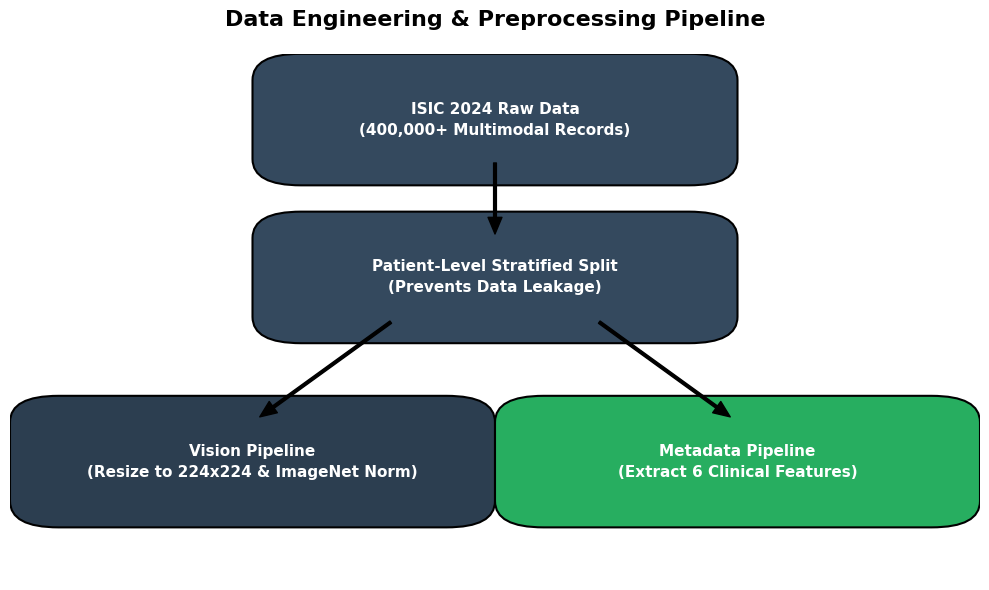

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_pipeline_flowchart():
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off') # Hide the grid and axes

    # Helper function to draw rounded boxes
    def draw_box(ax, text, x, y, width, height, facecolor='#34495E', textcolor='white'):
        box = patches.FancyBboxPatch(
            (x, y), width, height,
            boxstyle="round,pad=0.05",
            edgecolor='black', facecolor=facecolor, lw=1.5
        )
        ax.add_patch(box)
        ax.text(x + width/2, y + height/2, text,
                ha='center', va='center', color=textcolor,
                fontsize=11, fontweight='bold', family='sans-serif', linespacing=1.5)

    # 1. Top Node: Raw Data
    draw_box(ax, "ISIC 2024 Raw Data\n(400,000+ Multimodal Records)",
             x=0.3, y=0.8, width=0.4, height=0.15)

    # 2. Middle Node: Splitting
    draw_box(ax, "Patient-Level Stratified Split\n(Prevents Data Leakage)",
             x=0.3, y=0.5, width=0.4, height=0.15)

    # 3. Bottom Left Node: Vision Pipeline
    draw_box(ax, "Vision Pipeline\n(Resize to 224x224 & ImageNet Norm)",
             x=0.05, y=0.15, width=0.4, height=0.15, facecolor='#2C3E50') # Dark Blue

    # 4. Bottom Right Node: Metadata Pipeline
    draw_box(ax, "Metadata Pipeline\n(Extract 6 Clinical Features)",
             x=0.55, y=0.15, width=0.4, height=0.15, facecolor='#27AE60') # Green

    # Add Arrows
    arrowprops = dict(facecolor='black', edgecolor='black', width=2, headwidth=10, shrink=0.05)

    # Arrow: Raw Data -> Split
    ax.annotate('', xy=(0.5, 0.65), xytext=(0.5, 0.8), arrowprops=arrowprops)

    # Arrow: Split -> Vision
    ax.annotate('', xy=(0.25, 0.3), xytext=(0.4, 0.5), arrowprops=arrowprops)

    # Arrow: Split -> Metadata
    ax.annotate('', xy=(0.75, 0.3), xytext=(0.6, 0.5), arrowprops=arrowprops)

    # Title
    plt.title("Data Engineering & Preprocessing Pipeline", fontsize=16, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

# Execute to display in output cell
create_pipeline_flowchart()

/tmp/ipykernel_4895/45755268.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=auc_scores, palette=colors)


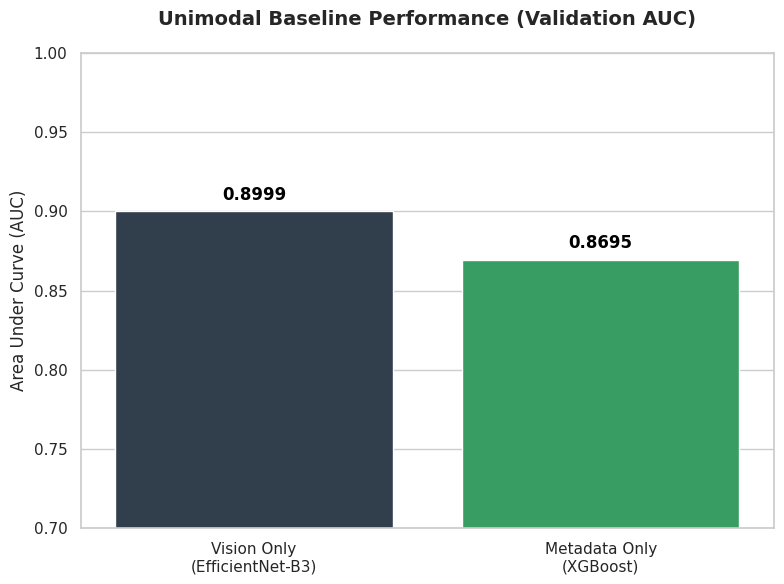

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def create_unimodal_comparison():
    # Data from your Phase 2 and Phase 3 results
    models = ['Vision Only\n(EfficientNet-B3)', 'Metadata Only\n(XGBoost)']
    auc_scores = [0.8999, 0.8695]

    # Setup styling
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 6))

    # Create bar plot
    colors = ['#2C3E50', '#27AE60'] # Match the blue/green theme from previous slides
    ax = sns.barplot(x=models, y=auc_scores, palette=colors)

    # Add labels and title
    plt.title('Unimodal Baseline Performance (Validation AUC)', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Area Under Curve (AUC)', fontsize=12)
    plt.ylim(0.7, 1.0) # Zoom in to show the difference clearly

    # Add value labels on top of bars
    for i, score in enumerate(auc_scores):
        ax.text(i, score + 0.005, f'{score:.4f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

    plt.tight_layout()
    plt.show()

# Execute to display
create_unimodal_comparison()

🎨 Generating Vision Baseline Confusion Matrix...
✅ Image saved to /content/drive/MyDrive/ISIC_2024/Fig04_Vision_CM.png


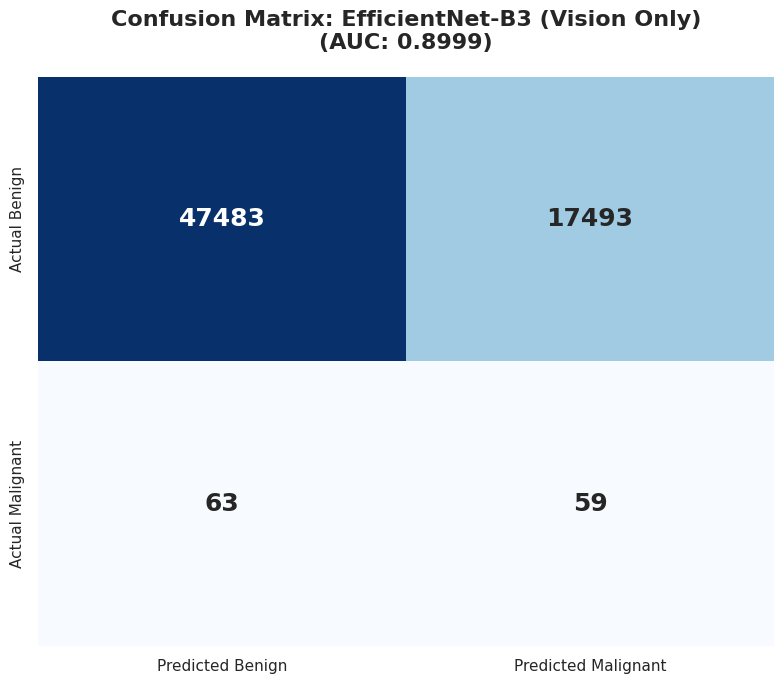

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# BASE_PATH is set in Cell 0 above

def generate_vision_cm():
    print("🎨 Generating Vision Baseline Confusion Matrix...")

    # Data from your Phase 2 Tracker for EfficientNet-B3
    # TP: 59, FP: 17493, TN: 47483, FN: 63
    cm = np.array([
        [47483, 17493],
        [63, 59]
    ])

    sns.set_theme(style="whitegrid", palette="deep")
    plt.figure(figsize=(8, 7))

    # Using a Blue colormap for Vision (to contrast with the Purple Fusion and Brown Metadata)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Benign', 'Predicted Malignant'],
                yticklabels=['Actual Benign', 'Actual Malignant'],
                annot_kws={"size": 18, "weight": "bold"})

    plt.title('Confusion Matrix: EfficientNet-B3 (Vision Only)\n(AUC: 0.8999)', pad=20, fontsize=16, fontweight='bold')
    plt.tight_layout()

    # Save the output
    save_path = os.path.join(BASE_PATH, 'Fig04_Vision_CM.png')
    try:
        plt.savefig(save_path, dpi=300)
        print(f"✅ Image saved to {save_path}")
    except FileNotFoundError:
        plt.savefig('Fig04_Vision_CM.png', dpi=300)
        print("✅ Image saved locally as 'Fig04_Vision_CM.png'")

    plt.show()

# Execute
generate_vision_cm()

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class IntermediateFusionModel(nn.Module):
    def __init__(self, num_metadata_features, num_classes=1):
        super(IntermediateFusionModel, self).__init__()

        # 1. Image Branch (CNN Backbone)
        # Using a pretrained ResNet34, removing the final classification layer
        resnet = models.resnet34(pretrained=True)
        self.image_feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        image_feature_dim = resnet.fc.in_features # Usually 512 for ResNet34

        # 2. Metadata Branch (MLP)
        self.metadata_encoder = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # 3. Fusion Head (Joint Dense Layers)
        # Combined dimension = image features + metadata features
        combined_dim = image_feature_dim + 32

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
            nn.Sigmoid() # For binary classification (Melanoma vs. Benign)
        )

    def forward(self, images, metadata):
        # Extract image features
        img_features = self.image_feature_extractor(images)
        img_features = torch.flatten(img_features, 1) # Shape: (Batch, 512)

        # Extract metadata features
        meta_features = self.metadata_encoder(metadata) # Shape: (Batch, 32)

        # Concatenate along the feature dimension
        fused_features = torch.cat((img_features, meta_features), dim=1) # Shape: (Batch, 544)

        # Final prediction
        output = self.classifier(fused_features)
        return output

# --- Example Usage ---
# images = torch.randn(8, 3, 224, 224) # Batch of 8 RGB images
# metadata = torch.randn(8, 10)        # Batch of 8 patients, 10 clinical features each
# model = IntermediateFusionModel(num_metadata_features=10)
# predictions = model(images, metadata)

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

def late_fusion_ensemble(cnn_probabilities, xgboost_probabilities, cnn_weight=0.6):
    """
    Combines the predictions of an image model and a tabular model.
    cnn_probabilities: numpy array of predictions from the PyTorch model
    xgboost_probabilities: numpy array of predictions from the XGBoost model
    cnn_weight: How much to trust the image model vs the clinical model
    """
    xgb_weight = 1.0 - cnn_weight

    # Weighted average of the probabilities
    fused_predictions = (cnn_probabilities * cnn_weight) + (xgboost_probabilities * xgb_weight)

    return fused_predictions

# Example weighting grid-search logic
# best_auc = 0
# best_weight = 0
# for weight in np.linspace(0, 1, 11):
#     ensemble_preds = late_fusion_ensemble(val_cnn_preds, val_xgb_preds, cnn_weight=weight)
#     auc = roc_auc_score(val_true_labels, ensemble_preds)
#     if auc > best_auc:
#         best_auc = auc
#         best_weight = weight
# print(f"Best Image Weight: {best_weight}, yielding AUC: {best_auc}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_rounded_box(ax, text, center_x, center_y, width, height, facecolor='#34495E', textcolor='white'):
    """Helper function to draw a centered, rounded box with text."""
    box = patches.FancyBboxPatch(
        (center_x - width/2, center_y - height/2), width, height,
        boxstyle="round,pad=0.05",
        edgecolor='black', facecolor=facecolor, lw=1.5
    )
    ax.add_patch(box)
    ax.text(center_x, center_y, text,
            ha='center', va='center', color=textcolor,
            fontsize=11, fontweight='bold', family='sans-serif')

def draw_arrow(ax, start_x, start_y, end_x, end_y):
    """Helper function to draw a simple arrow."""
    ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8, shrink=0.0))

# ==========================================
# 1. Early Fusion Architecture
# ==========================================
def create_early_fusion_diagram():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.axis('off')

    # Nodes
    draw_rounded_box(ax, "Image Input\n(Pixels)", 0.3, 0.8, 0.3, 0.15)
    draw_rounded_box(ax, "Metadata Input\n(Age, Sex, etc.)", 0.7, 0.8, 0.3, 0.15)
    draw_rounded_box(ax, "Data Concatenation\n(Channel Stacking)", 0.5, 0.55, 0.5, 0.15, facecolor='#8E44AD') # Purple
    draw_rounded_box(ax, "CNN Feature Extraction", 0.5, 0.3, 0.4, 0.15, facecolor='#2C3E50')
    draw_rounded_box(ax, "Final Prediction", 0.5, 0.05, 0.3, 0.15, facecolor='#E74C3C')

    # Arrows
    draw_arrow(ax, 0.3, 0.725, 0.4, 0.625)
    draw_arrow(ax, 0.7, 0.725, 0.6, 0.625)
    draw_arrow(ax, 0.5, 0.475, 0.5, 0.375)
    draw_arrow(ax, 0.5, 0.225, 0.5, 0.125)

    plt.title("Early Fusion (Data-Level)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('Fig06_Early_Fusion.png', dpi=300, bbox_inches='tight')
    print("✅ Saved Fig06_Early_Fusion.png")
    plt.close()

# ==========================================
# 2. Intermediate Fusion Architecture
# ==========================================
def create_intermediate_fusion_diagram():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    # Nodes - Image Path
    draw_rounded_box(ax, "Image Input", 0.25, 0.85, 0.3, 0.12)
    draw_rounded_box(ax, "CNN Extractor", 0.25, 0.65, 0.3, 0.12, facecolor='#2C3E50')
    draw_rounded_box(ax, "Image Features\n(e.g., 512D)", 0.25, 0.45, 0.3, 0.12, facecolor='#2980B9')

    # Nodes - Metadata Path
    draw_rounded_box(ax, "Metadata Input", 0.75, 0.85, 0.3, 0.12)
    draw_rounded_box(ax, "MLP Extractor", 0.75, 0.65, 0.3, 0.12, facecolor='#27AE60')
    draw_rounded_box(ax, "Tabular Features\n(e.g., 64D)", 0.75, 0.45, 0.3, 0.12, facecolor='#2ECC71')

    # Fusion Node
    draw_rounded_box(ax, "Concatenate Vectors &\nJoint Dense Layers", 0.5, 0.25, 0.5, 0.15, facecolor='#8E44AD')

    # Prediction
    draw_rounded_box(ax, "Final Prediction", 0.5, 0.05, 0.3, 0.12, facecolor='#E74C3C')

    # Arrows
    draw_arrow(ax, 0.25, 0.79, 0.25, 0.71)
    draw_arrow(ax, 0.25, 0.59, 0.25, 0.51)
    draw_arrow(ax, 0.75, 0.79, 0.75, 0.71)
    draw_arrow(ax, 0.75, 0.59, 0.75, 0.51)
    draw_arrow(ax, 0.25, 0.39, 0.4, 0.325)
    draw_arrow(ax, 0.75, 0.39, 0.6, 0.325)
    draw_arrow(ax, 0.5, 0.175, 0.5, 0.11)

    plt.title("Intermediate Fusion (Feature-Level)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('Fig07_Intermediate_Fusion.png', dpi=300, bbox_inches='tight')
    print("✅ Saved Fig07_Intermediate_Fusion.png")
    plt.close()

# ==========================================
# 3. Late Fusion Architecture
# ==========================================
def create_late_fusion_diagram():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axis('off')

    # Nodes - Image Path
    draw_rounded_box(ax, "Image Input", 0.25, 0.85, 0.3, 0.12)
    draw_rounded_box(ax, "CNN Model", 0.25, 0.65, 0.3, 0.12, facecolor='#2C3E50')
    draw_rounded_box(ax, "Prob = 0.85", 0.25, 0.45, 0.2, 0.12, facecolor='#2980B9')

    # Nodes - Metadata Path
    draw_rounded_box(ax, "Metadata Input", 0.75, 0.85, 0.3, 0.12)
    draw_rounded_box(ax, "XGBoost Model", 0.75, 0.65, 0.3, 0.12, facecolor='#27AE60')
    draw_rounded_box(ax, "Prob = 0.90", 0.75, 0.45, 0.2, 0.12, facecolor='#2ECC71')

    # Fusion Node
    draw_rounded_box(ax, "Decision Ensemble\n(Weighted Average)", 0.5, 0.25, 0.5, 0.15, facecolor='#8E44AD')

    # Prediction
    draw_rounded_box(ax, "Final Prediction", 0.5, 0.05, 0.3, 0.12, facecolor='#E74C3C')

    # Arrows
    draw_arrow(ax, 0.25, 0.79, 0.25, 0.71)
    draw_arrow(ax, 0.25, 0.59, 0.25, 0.51)
    draw_arrow(ax, 0.75, 0.79, 0.75, 0.71)
    draw_arrow(ax, 0.75, 0.59, 0.75, 0.51)
    draw_arrow(ax, 0.25, 0.39, 0.4, 0.325)
    draw_arrow(ax, 0.75, 0.39, 0.6, 0.325)
    draw_arrow(ax, 0.5, 0.175, 0.5, 0.11)

    plt.title("Late Fusion (Decision-Level)", fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('Fig08_Late_Fusion.png', dpi=300, bbox_inches='tight')
    print("✅ Saved Fig08_Late_Fusion.png")
    plt.close()

# Execute all functions
create_early_fusion_diagram()
create_intermediate_fusion_diagram()
create_late_fusion_diagram()

✅ Saved Fig06_Early_Fusion.png
✅ Saved Fig07_Intermediate_Fusion.png
✅ Saved Fig08_Late_Fusion.png


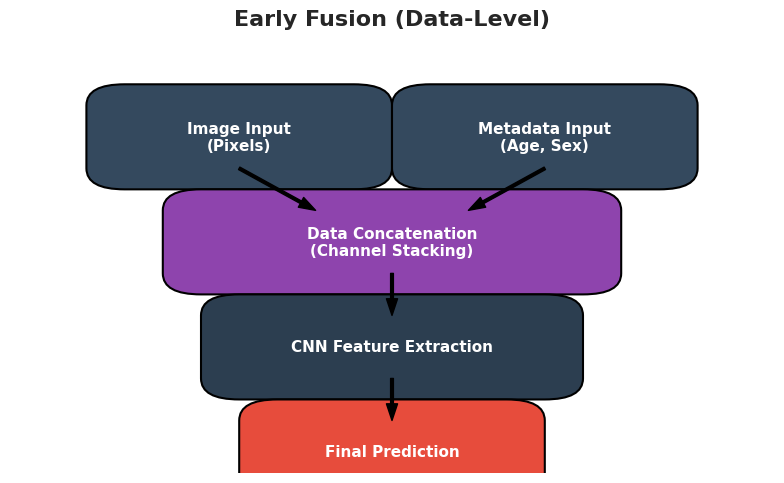

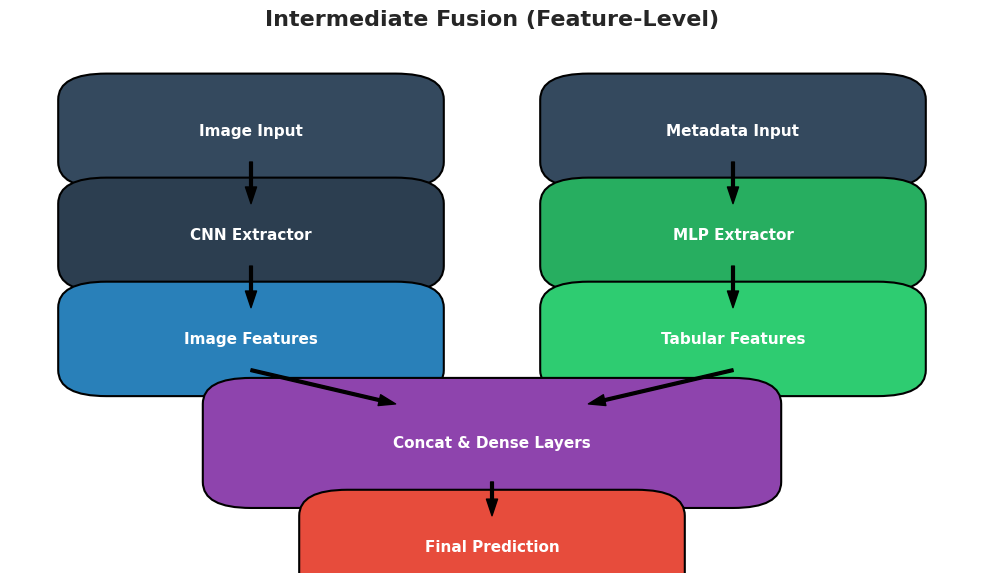

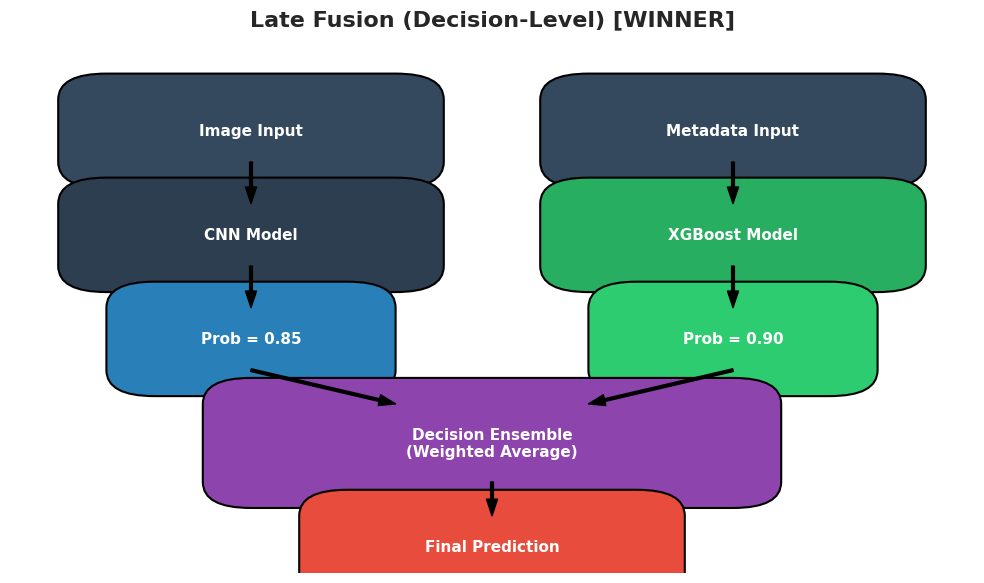

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_rounded_box(ax, text, center_x, center_y, width, height, facecolor='#34495E', textcolor='white'):
    box = patches.FancyBboxPatch(
        (center_x - width/2, center_y - height/2), width, height,
        boxstyle="round,pad=0.05",
        edgecolor='black', facecolor=facecolor, lw=1.5
    )
    ax.add_patch(box)
    ax.text(center_x, center_y, text,
            ha='center', va='center', color=textcolor,
            fontsize=11, fontweight='bold', family='sans-serif')

def draw_arrow(ax, start_x, start_y, end_x, end_y):
    ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                arrowprops=dict(facecolor='black', edgecolor='black', width=2, headwidth=8, shrink=0.0))

# ================================
# 1. Early Fusion
# ================================
fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.axis('off')
draw_rounded_box(ax1, "Image Input\n(Pixels)", 0.3, 0.8, 0.3, 0.15)
draw_rounded_box(ax1, "Metadata Input\n(Age, Sex)", 0.7, 0.8, 0.3, 0.15)
draw_rounded_box(ax1, "Data Concatenation\n(Channel Stacking)", 0.5, 0.55, 0.5, 0.15, facecolor='#8E44AD')
draw_rounded_box(ax1, "CNN Feature Extraction", 0.5, 0.3, 0.4, 0.15, facecolor='#2C3E50')
draw_rounded_box(ax1, "Final Prediction", 0.5, 0.05, 0.3, 0.15, facecolor='#E74C3C')
draw_arrow(ax1, 0.3, 0.725, 0.4, 0.625)
draw_arrow(ax1, 0.7, 0.725, 0.6, 0.625)
draw_arrow(ax1, 0.5, 0.475, 0.5, 0.375)
draw_arrow(ax1, 0.5, 0.225, 0.5, 0.125)
plt.title("Early Fusion (Data-Level)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ================================
# 2. Intermediate Fusion
# ================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.axis('off')
draw_rounded_box(ax2, "Image Input", 0.25, 0.85, 0.3, 0.12)
draw_rounded_box(ax2, "CNN Extractor", 0.25, 0.65, 0.3, 0.12, facecolor='#2C3E50')
draw_rounded_box(ax2, "Image Features", 0.25, 0.45, 0.3, 0.12, facecolor='#2980B9')
draw_rounded_box(ax2, "Metadata Input", 0.75, 0.85, 0.3, 0.12)
draw_rounded_box(ax2, "MLP Extractor", 0.75, 0.65, 0.3, 0.12, facecolor='#27AE60')
draw_rounded_box(ax2, "Tabular Features", 0.75, 0.45, 0.3, 0.12, facecolor='#2ECC71')
draw_rounded_box(ax2, "Concat & Dense Layers", 0.5, 0.25, 0.5, 0.15, facecolor='#8E44AD')
draw_rounded_box(ax2, "Final Prediction", 0.5, 0.05, 0.3, 0.12, facecolor='#E74C3C')
draw_arrow(ax2, 0.25, 0.79, 0.25, 0.71)
draw_arrow(ax2, 0.25, 0.59, 0.25, 0.51)
draw_arrow(ax2, 0.75, 0.79, 0.75, 0.71)
draw_arrow(ax2, 0.75, 0.59, 0.75, 0.51)
draw_arrow(ax2, 0.25, 0.39, 0.4, 0.325)
draw_arrow(ax2, 0.75, 0.39, 0.6, 0.325)
draw_arrow(ax2, 0.5, 0.175, 0.5, 0.11)
plt.title("Intermediate Fusion (Feature-Level)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ================================
# 3. Late Fusion (The Winner)
# ================================
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.axis('off')
draw_rounded_box(ax3, "Image Input", 0.25, 0.85, 0.3, 0.12)
draw_rounded_box(ax3, "CNN Model", 0.25, 0.65, 0.3, 0.12, facecolor='#2C3E50')
draw_rounded_box(ax3, "Prob = 0.85", 0.25, 0.45, 0.2, 0.12, facecolor='#2980B9')
draw_rounded_box(ax3, "Metadata Input", 0.75, 0.85, 0.3, 0.12)
draw_rounded_box(ax3, "XGBoost Model", 0.75, 0.65, 0.3, 0.12, facecolor='#27AE60')
draw_rounded_box(ax3, "Prob = 0.90", 0.75, 0.45, 0.2, 0.12, facecolor='#2ECC71')
draw_rounded_box(ax3, "Decision Ensemble\n(Weighted Average)", 0.5, 0.25, 0.5, 0.15, facecolor='#8E44AD')
draw_rounded_box(ax3, "Final Prediction", 0.5, 0.05, 0.3, 0.12, facecolor='#E74C3C')
draw_arrow(ax3, 0.25, 0.79, 0.25, 0.71)
draw_arrow(ax3, 0.25, 0.59, 0.25, 0.51)
draw_arrow(ax3, 0.75, 0.79, 0.75, 0.71)
draw_arrow(ax3, 0.75, 0.59, 0.75, 0.51)
draw_arrow(ax3, 0.25, 0.39, 0.4, 0.325)
draw_arrow(ax3, 0.75, 0.39, 0.6, 0.325)
draw_arrow(ax3, 0.5, 0.175, 0.5, 0.11)
plt.title("Late Fusion (Decision-Level) [WINNER]", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def plot_real_optimization_curve(y_true, cnn_preds, xgb_preds):
    print("⚙️ Calculating real AUC scores across all weight blends...")

    weights = np.linspace(0, 1, 101) # Tests 0.00 to 1.00 in increments of 0.01
    aucs = []

    # Calculate the exact AUC for every possible weight blend
    for w in weights:
        # Ensemble formula: w * Vision + (1-w) * Tabular
        fused_preds = (w * cnn_preds) + ((1 - w) * xgb_preds)
        auc = roc_auc_score(y_true, fused_preds)
        aucs.append(auc)

    # Find the actual empirical peak
    max_auc = max(aucs)
    best_weight = weights[aucs.index(max_auc)]

    print(f"✅ Found peak AUC of {max_auc:.4f} at Vision Weight: {best_weight:.2f}")

    # --- Plotting the Real Data ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the actual curve
    ax.plot(weights, aucs, color='#8E44AD', lw=4, label='Empirical Ensemble AUC')

    # Highlight the key points
    ax.scatter([0], [aucs[0]], color='#27AE60', s=150, zorder=5, edgecolors='black', label=f'Pure Tabular (AUC: {aucs[0]:.4f})')
    ax.scatter([1], [aucs[-1]], color='#2C3E50', s=150, zorder=5, edgecolors='black', label=f'Pure Vision (AUC: {aucs[-1]:.4f})')
    ax.scatter([best_weight], [max_auc], color='#F1C40F', s=350, zorder=5, marker='*', edgecolors='black', label=f'Peak Peak (AUC: {max_auc:.4f})')

    # Formatting
    ax.set_title('Late Fusion Weight Optimization (Real Validation Data)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Weight Assigned to Vision Model Prediction', fontsize=14, fontweight='bold')
    ax.set_ylabel('Validation ROC-AUC', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Annotations
    ax.axvline(x=best_weight, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=max_auc, color='black', linestyle='--', alpha=0.5)

    # Add a custom text box
    info_text = (
        f"Optimal Empirical Formula:\n"
        f"P(Final) = {best_weight:.2f} × P(CNN) + {1-best_weight:.2f} × P(XGB)"
    )

    # Dynamically place the text box so it doesn't overlap the curve
    y_text_pos = min(aucs) + (max(aucs) - min(aucs)) * 0.2
    ax.text(best_weight, y_text_pos, info_text,
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='#ECF0F1', edgecolor='black', boxstyle='round,pad=0.5', lw=1.5))

    # X-axis percentage formatting
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])

    ax.legend(loc='lower center', fontsize=11, framealpha=1.0)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/Fig25_Real_Ensemble_Weight_Search.png', dpi=300, facecolor='white')
    print("✅ Real optimization graph saved to Drive as 'Fig25_Real_Ensemble_Weight_Search.png'")
    plt.show()

🎨 Generating EfficientNet-B3 Architecture Diagram...
✅ Saved directly to Drive: /content/drive/MyDrive/ISIC_2024/Fig23_EfficientNetB3_Architecture.png


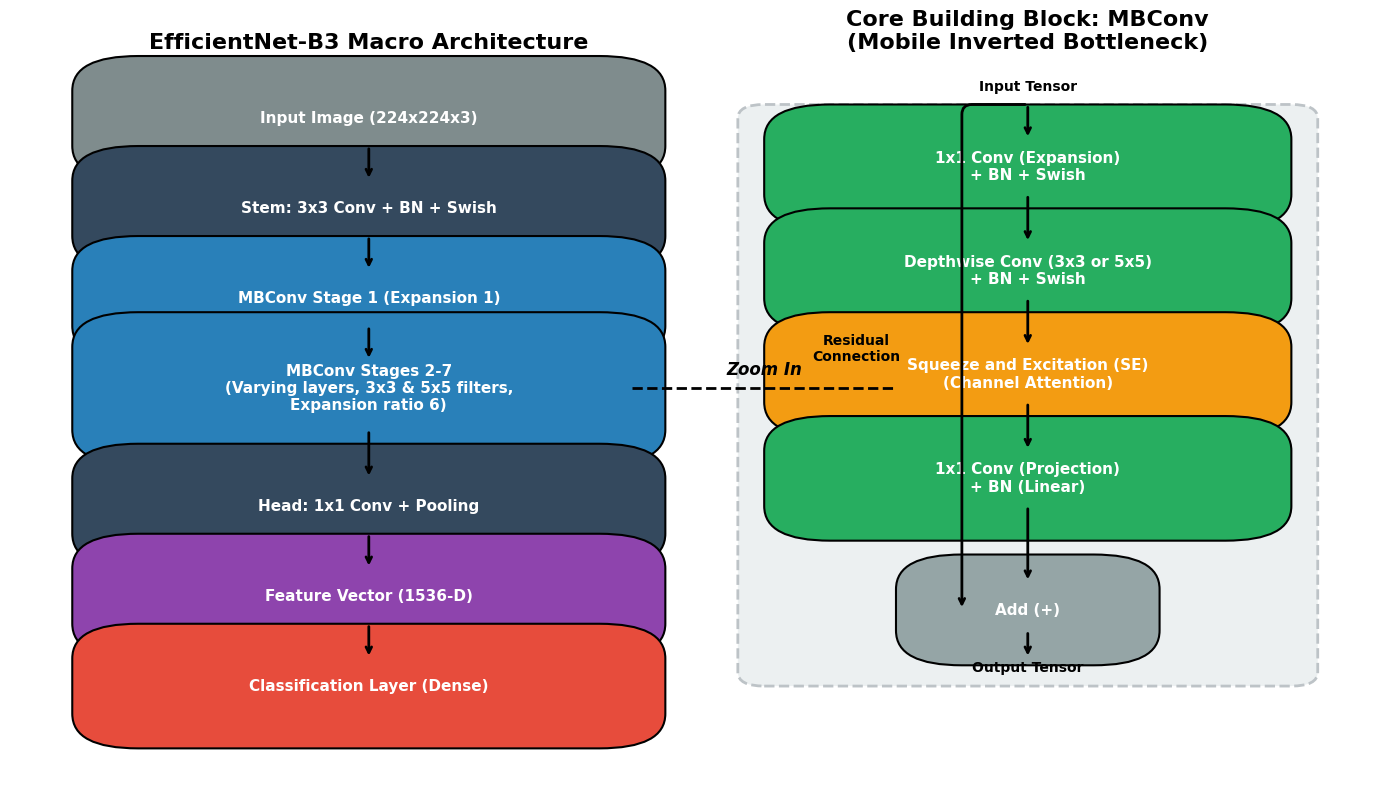

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

# Set your specific Google Drive path
# BASE_PATH is set in Cell 0 above

def generate_efficientnet_architecture():
    print("🎨 Generating EfficientNet-B3 Architecture Diagram...")
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axis('off')

    # Helper functions
    def draw_box(x, y, width, height, text, facecolor='#2C3E50', textcolor='white', fontsize=11):
        box = patches.FancyBboxPatch(
            (x - width/2, y - height/2), width, height,
            boxstyle="round,pad=0.05", edgecolor='black', facecolor=facecolor, lw=1.5
        )
        ax.add_patch(box)
        ax.text(x, y, text, ha='center', va='center', color=textcolor,
                fontsize=fontsize, fontweight='bold', family='sans-serif')

    def draw_arrow(x1, y1, x2, y2, rad="0.0"):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color='black', lw=2,
                                    connectionstyle=f"arc3,rad={rad}"))

    # LEFT PANEL: MACRO ARCHITECTURE
    ax.text(0.25, 0.95, "EfficientNet-B3 Macro Architecture", ha='center', fontsize=16, fontweight='bold')

    draw_box(0.25, 0.85, 0.35, 0.08, "Input Image (224x224x3)", facecolor='#7F8C8D')
    draw_arrow(0.25, 0.81, 0.25, 0.76)
    draw_box(0.25, 0.72, 0.35, 0.08, "Stem: 3x3 Conv + BN + Swish", facecolor='#34495E')
    draw_arrow(0.25, 0.68, 0.25, 0.63)
    draw_box(0.25, 0.59, 0.35, 0.08, "MBConv Stage 1 (Expansion 1)", facecolor='#2980B9')
    draw_arrow(0.25, 0.55, 0.25, 0.50)
    draw_box(0.25, 0.46, 0.35, 0.12, "MBConv Stages 2-7\n(Varying layers, 3x3 & 5x5 filters,\nExpansion ratio 6)", facecolor='#2980B9')
    draw_arrow(0.25, 0.40, 0.25, 0.33)
    draw_box(0.25, 0.29, 0.35, 0.08, "Head: 1x1 Conv + Pooling", facecolor='#34495E')
    draw_arrow(0.25, 0.25, 0.25, 0.20)
    draw_box(0.25, 0.16, 0.35, 0.08, "Feature Vector (1536-D)", facecolor='#8E44AD')
    draw_arrow(0.25, 0.12, 0.25, 0.07)
    draw_box(0.25, 0.03, 0.35, 0.08, "Classification Layer (Dense)", facecolor='#E74C3C')

    # Connection line to Right Panel
    ax.plot([0.45, 0.65], [0.46, 0.46], color='black', lw=2, linestyle='--')
    ax.text(0.55, 0.48, "Zoom In", ha='center', fontsize=12, fontweight='bold', style='italic')

    # RIGHT PANEL: MICRO ARCHITECTURE (MBConv Block)
    ax.text(0.75, 0.95, "Core Building Block: MBConv\n(Mobile Inverted Bottleneck)", ha='center', fontsize=16, fontweight='bold')

    mbconv_bg = patches.FancyBboxPatch(
        (0.55, 0.05), 0.4, 0.8,
        boxstyle="round,pad=0.02", edgecolor='#BDC3C7', facecolor='#ECF0F1', lw=2, linestyle='--'
    )
    ax.add_patch(mbconv_bg)

    draw_box(0.75, 0.78, 0.3, 0.08, "1x1 Conv (Expansion)\n+ BN + Swish", facecolor='#27AE60')
    draw_arrow(0.75, 0.74, 0.75, 0.67)
    draw_box(0.75, 0.63, 0.3, 0.08, "Depthwise Conv (3x3 or 5x5)\n+ BN + Swish", facecolor='#27AE60')
    draw_arrow(0.75, 0.59, 0.75, 0.52)
    draw_box(0.75, 0.48, 0.3, 0.08, "Squeeze and Excitation (SE)\n(Channel Attention)", facecolor='#F39C12')
    draw_arrow(0.75, 0.44, 0.75, 0.37)
    draw_box(0.75, 0.33, 0.3, 0.08, "1x1 Conv (Projection)\n+ BN (Linear)", facecolor='#27AE60')
    draw_arrow(0.75, 0.29, 0.75, 0.18)
    draw_box(0.75, 0.14, 0.1, 0.06, "Add (+)", facecolor='#95A5A6')

    # Residual Connection
    ax.annotate('', xy=(0.7, 0.14), xytext=(0.75, 0.87),
                arrowprops=dict(arrowstyle="->", color='black', lw=2,
                                connectionstyle="angle,angleA=0,angleB=-90,rad=10"))
    ax.text(0.62, 0.5, "Residual\nConnection", ha='center', fontsize=10, fontweight='bold')

    draw_arrow(0.75, 0.87, 0.75, 0.82)
    ax.text(0.75, 0.89, "Input Tensor", ha='center', fontsize=10, fontweight='bold')
    draw_arrow(0.75, 0.11, 0.75, 0.07)
    ax.text(0.75, 0.05, "Output Tensor", ha='center', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Save directly to your Drive
    save_path = os.path.join(BASE_PATH, 'Fig23_EfficientNetB3_Architecture.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Saved directly to Drive: {save_path}")
    plt.show()

# Execute
generate_efficientnet_architecture()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

# Set your specific Google Drive path
# BASE_PATH is set in Cell 0 above

def plot_real_optimization_curve(y_true, cnn_preds, xgb_preds):
    print("⚙️ Calculating real AUC scores across all weight blends...")

    weights = np.linspace(0, 1, 101) # Tests 0.00 to 1.00 in increments of 0.01
    aucs = []

    # Calculate the exact AUC for every possible weight blend
    for w in weights:
        # Ensemble formula: w * Vision + (1-w) * Tabular
        fused_preds = (w * cnn_preds) + ((1 - w) * xgb_preds)
        auc = roc_auc_score(y_true, fused_preds)
        aucs.append(auc)

    # Find the actual empirical peak
    max_auc = max(aucs)
    best_weight = weights[aucs.index(max_auc)]

    print(f"✅ Found peak AUC of {max_auc:.4f} at Vision Weight: {best_weight:.2f}")

    # --- Plotting the Real Data ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the actual curve
    ax.plot(weights, aucs, color='#8E44AD', lw=4, label='Empirical Ensemble AUC')

    # Highlight the key points
    ax.scatter([0], [aucs[0]], color='#27AE60', s=150, zorder=5, edgecolors='black', label=f'Pure Tabular (AUC: {aucs[0]:.4f})')
    ax.scatter([1], [aucs[-1]], color='#2C3E50', s=150, zorder=5, edgecolors='black', label=f'Pure Vision (AUC: {aucs[-1]:.4f})')
    ax.scatter([best_weight], [max_auc], color='#F1C40F', s=350, zorder=5, marker='*', edgecolors='black', label=f'Peak Performance (AUC: {max_auc:.4f})')

    # Formatting
    ax.set_title('Late Fusion Weight Optimization (Real Validation Data)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Weight Assigned to Vision Model Prediction', fontsize=14, fontweight='bold')
    ax.set_ylabel('Validation ROC-AUC', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.7)

    # Annotations
    ax.axvline(x=best_weight, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y=max_auc, color='black', linestyle='--', alpha=0.5)

    # Add a custom text box dynamically placed
    info_text = (
        f"Optimal Empirical Formula:\n"
        f"P(Final) = {best_weight:.2f} × P(CNN) + {1-best_weight:.2f} × P(XGB)"
    )
    y_text_pos = min(aucs) + (max(aucs) - min(aucs)) * 0.2
    ax.text(best_weight, y_text_pos, info_text,
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='#ECF0F1', edgecolor='black', boxstyle='round,pad=0.5', lw=1.5))

    # X-axis percentage formatting
    ax.set_xticks(np.arange(0, 1.1, 0.1))
    ax.set_xticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.1, 0.1)])

    ax.legend(loc='lower center', fontsize=11, framealpha=1.0)
    plt.tight_layout()

    # Save directly to your Drive folder
    save_path = os.path.join(BASE_PATH, 'Fig25_Real_Ensemble_Weight_Search.png')
    plt.savefig(save_path, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"✅ Saved directly to Drive: {save_path}")
    plt.show()

# ==========================================
# EXECUTION: LOAD YOUR DATA AND RUN
# ==========================================

try:
    print("📂 Loading data from Google Drive...")

    # --- IF YOU SAVED AS CSV, UNCOMMENT AND USE THIS BLOCK ---

    csv_path = os.path.join(BASE_PATH, 'validation_predictions.csv') # <-- REPLACE with your actual CSV name
    df = pd.read_csv(csv_path)
    val_y_true = df['target'].values              # <-- Ensure column name matches
    val_cnn_preds = df['cnn_probability'].values  # <-- Ensure column name matches
    val_xgb_preds = df['xgb_probability'].values  # <-- Ensure column name matches


    # --- IF YOU SAVED AS .NPY ARRAYS, UNCOMMENT AND USE THIS BLOCK ---

    val_y_true = np.load(os.path.join(BASE_PATH, 'val_labels.npy'))       # <-- REPLACE with your actual file name
    val_cnn_preds = np.load(os.path.join(BASE_PATH, 'cnn_preds.npy'))     # <-- REPLACE with your actual file name
    val_xgb_preds = np.load(os.path.join(BASE_PATH, 'xgb_preds.npy'))     # <-- REPLACE with your actual file name


    # Generate the graph
    plot_real_optimization_curve(val_y_true, val_cnn_preds, val_xgb_preds)

    print("⚠️ Please uncomment the data loading section that matches your files to generate the graph!")

except FileNotFoundError as e:
    print(f"❌ Error finding files: {e}")
    print("Make sure the file names in the code match exactly what is in your ISIC_2024 folder!")

📂 Loading data from Google Drive...
❌ Error finding files: [Errno 2] No such file or directory: '/content/drive/MyDrive/ISIC_2024/validation_predictions.csv'
Make sure the file names in the code match exactly what is in your ISIC_2024 folder!
